<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
Crime Data Analysis
</h1>

<h2 style="color:#2471A3;">Introduction</h2>

<p style="font-size:16px;text-align:justify;">
Crime data analysis plays an important role in understanding crime patterns, identifying high-risk areas, and supporting public safety initiatives. This dataset contains information about reported crime incidents, including occurrence dates, locations, victim demographics, weapon usage, and case status. The objective of this project is to clean, preprocess, and analyze the crime dataset to uncover meaningful insights through exploratory data analysis and visualization.
</p>

<h2 style="color:#2471A3;">Data Source</h2>

<p style="font-size:16px;">
The dataset used in this project was collected through the
<a href="https://catalog.data.gov/?q=crime+data" target="_blank">
Data.gov Catalog
</a>, which provides access to publicly available government datasets. The original dataset was obtained from the Los Angeles Open Data portal.
</p>

<p style="font-size:16px;">
<b>Note:-</b> The original file name was
<b>"Crime_Data_from_2020_to_2024.csv"</b>, but I renamed it to
<b>"Crime Data Analysis.csv"</b>. Only the file name was changed; the data structure and contents remain unchanged.
</p>

<h2 style="color:#2471A3;">Importing Required Libraries</h2>

In [1]:
import pandas as pd
import numpy as np

<h2 style="color:#2471A3;">Loading the Dataset</h2>

<p>
The dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.
</p>

In [2]:
df = pd.read_csv("Crime_Data_from_2020_to_2024.csv")
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


<h2 style="color:#2471A3;">Dataset Overview</h2>

<p>
Understanding the dimensions, structure, and attributes of the dataset before cleaning.
</p>

In [3]:
print("Rows and Columns:", df.shape)
df.info()

Rows and Columns: (1004894, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weap

<h2 style="color:#2471A3;">Selecting Relevant Columns</h2>

<p>
The original dataset contained 30 attributes. Only the columns required for crime analysis were retained to reduce complexity and improve interpretability.
</p>

In [4]:
print(df.columns.tolist())

['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON']


In [5]:
df.columns = df.columns.str.strip()

In [6]:
df = df[
    [
        'DR_NO',
        'Date Rptd',
        'DATE OCC',
        'TIME OCC',
        'Vict Age',
        'Vict Sex',
        'Vict Descent',
        'Status Desc',
        'Weapon Desc',
        'Crm Cd Desc',
        'AREA NAME',
        'Premis Desc'
    ]
]

In [7]:
df.shape

(1004894, 12)

<h1 style="text-align:center;color:white;background-color:#1F618D;padding:10px;border-radius:8px;">
Data Cleaning and Preprocessing
</h1>

<h2 style="color:#2471A3;">Removing Duplicate Records</h2>

<p>
Duplicate crime records can affect the accuracy of analysis. Duplicate Crime IDs are removed to ensure uniqueness.
</p>

In [8]:
df = df.drop_duplicates(subset='DR_NO')

<h2 style="color:#2471A3;">Date Standardization</h2>

<p>
Date fields are converted into a standard datetime format for easier analysis and sorting.
</p>

In [9]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

<h2 style="color:#2471A3;">Time Format Conversion</h2>

<p>
Occurrence time is converted into a readable 12-hour format with AM/PM notation.
</p>

In [10]:
df['TIME OCC'] = pd.to_numeric(df['TIME OCC'], errors='coerce')

df = df[df['TIME OCC'].notna()]

df['TIME OCC'] = (
    df['TIME OCC']
    .astype(int)
    .astype(str)
    .str.zfill(4)
)

df['TIME OCC'] = pd.to_datetime(
    df['TIME OCC'],
    format='%H%M',
    errors='coerce'
).dt.strftime('%I:%M:%S %p')

<h2 style="color:#2471A3;">Renaming Columns</h2>

<p>
Column names are renamed to improve readability and maintain consistency throughout the analysis.
</p>

In [11]:
df.rename(columns={
    'DR_NO':'CRIME_ID',
    'Date Rptd':'REPORT_DATE',
    'DATE OCC':'OCCURANCE_DATE',
    'TIME OCC':'OCCURANCE_TIME',
    'AREA NAME':'AREA',
    'Crm Cd Desc':'CRIME_TYPE',
    'Vict Age':'VICTIM_AGE',
    'Vict Sex':'VICTIM_GENDER',
    'Vict Descent':'VICTIM_ETHNICITY',
    'Premis Desc':'LOCATION',
    'Weapon Desc':'WEAPON_USED',
    'Status Desc':'CASE_STATUS'
}, inplace=True)

<h2 style="color:#2471A3;">Gender Value Standardization</h2>

In [12]:
df['VICTIM_GENDER'] = df['VICTIM_GENDER'].replace({
    'M':'Male',
    'F':'Female'
})

<h2 style="color:#2471A3;">Ethnicity Value Standardization</h2>

In [13]:
df['VICTIM_ETHNICITY'] = df['VICTIM_ETHNICITY'].replace({
    'B':'Black',
    'W':'White'
})

<h2 style="color:#2471A3;">Targeted Category Filtering</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
The dataset is subsetted to isolate key investigative fields. Victim demographics are restricted exclusively to Black and White profiles, while case statuses are limited strictly to active tracking indicators: Invest Cont, Juv Arrest, and Adult Arrest.
</p>

In [14]:
df = df[df['VICTIM_ETHNICITY'].isin(['Black', 'White'])]
df = df[df['CASE_STATUS'].isin(['Invest Cont', 'Juv Arrest', 'Adult Arrest'])]

print("Confirmed Unique Ethnicities:", df['VICTIM_ETHNICITY'].unique())
print("Confirmed Unique Case Statuses:", df['CASE_STATUS'].unique())

Confirmed Unique Ethnicities: ['White' 'Black']
Confirmed Unique Case Statuses: ['Invest Cont' 'Adult Arrest' 'Juv Arrest']


<h2 style="color:#2471A3;">Case Status Mapping and Expansion</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
To enhance clarity across analytics and reporting dashboards, shorthand case status tracking codes are mapped and expanded to their formal nomenclature descriptions.
</p>

In [15]:
df['CASE_STATUS'] = df['CASE_STATUS'].replace({
    'Invest Cont': 'Investigation Continued',
    'Juv Arrest': 'Juvenile Arrest'
})

print("Expanded Case Status Forms:")
print(df['CASE_STATUS'].unique())

Expanded Case Status Forms:
['Investigation Continued' 'Adult Arrest' 'Juvenile Arrest']


<h2 style="color:#2471A3;">Excluding Unknown Weapon Variations</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
Records missing clear weapon logs or matching text variations of unknown descriptors—including compound labels like UNKNOWN WEAPON/OTHER WEAPON—are permanently purged from the dataframe.
</p>

In [16]:
df = df.dropna(subset=['WEAPON_USED'])

df['WEAPON_USED'] = df['WEAPON_USED'].astype(str).str.strip()

df = df[~df['WEAPON_USED'].isin([
    'UNK WEAPON', 
    'UNKNOWN WEAPON', 
    'UNKNOWN WEAPON/OTHER WEAPON', 
    'UNKNOWN FIREARM',
    'nan',
    'None'
])]

print("Sample of Verified Weapon Descriptions remaining:")
print(df['WEAPON_USED'].unique()[:10])

Sample of Verified Weapon Descriptions remaining:
['STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)' 'VERBAL THREAT'
 'AIR PISTOL/REVOLVER/RIFLE/BB GUN' 'HAND GUN' 'SEMI-AUTOMATIC PISTOL'
 'STICK' 'OTHER KNIFE' 'REVOLVER' 'VEHICLE' 'BOTTLE']


<h2 style="color:#2471A3;">Removing Invalid Age Records</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
Statistical anomalies, such as victim age values recorded at zero or below, are expunged to maintain structural demographic integrity.
</p>

In [17]:
df = df[(df['VICTIM_AGE'] > 0) & (df['VICTIM_AGE'] <= 100)]

<h2 style="color:#2471A3;">Inspecting Dataset Columns</h2>

In [18]:
df.columns

Index(['CRIME_ID', 'REPORT_DATE', 'OCCURANCE_DATE', 'OCCURANCE_TIME',
       'VICTIM_AGE', 'VICTIM_GENDER', 'VICTIM_ETHNICITY', 'CASE_STATUS',
       'WEAPON_USED', 'CRIME_TYPE', 'AREA', 'LOCATION'],
      dtype='object')

<h2 style="color:#2471A3;">Checking Duplicate Crime IDs</h2>

In [19]:
df['CRIME_ID'].duplicated().sum()

0

<h2 style="color:#2471A3;">Missing Value Analysis</h2>

<p>
The dataset is checked for missing values to ensure completeness and reliability.
</p>

In [20]:
df.isnull().sum()

CRIME_ID             0
REPORT_DATE          0
OCCURANCE_DATE       0
OCCURANCE_TIME       0
VICTIM_AGE           0
VICTIM_GENDER        0
VICTIM_ETHNICITY     0
CASE_STATUS          0
WEAPON_USED          0
CRIME_TYPE           0
AREA                 0
LOCATION            28
dtype: int64

<h2 style="color:#2471A3;">Feature Engineering - Age Groups</h2>

<p>
Victims are categorized into age groups to simplify demographic analysis.
</p>

In [21]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 30:
        return 'Young Adult'
    elif age < 50:
        return 'Adult'
    else:
        return 'Senior'

df['AGE_GROUP'] = df['VICTIM_AGE'].apply(age_group)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 73939 entries, 16 to 1004892
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CRIME_ID          73939 non-null  int64         
 1   REPORT_DATE       73939 non-null  datetime64[ns]
 2   OCCURANCE_DATE    73939 non-null  datetime64[ns]
 3   OCCURANCE_TIME    73939 non-null  object        
 4   VICTIM_AGE        73939 non-null  int64         
 5   VICTIM_GENDER     73939 non-null  object        
 6   VICTIM_ETHNICITY  73939 non-null  object        
 7   CASE_STATUS       73939 non-null  object        
 8   WEAPON_USED       73939 non-null  object        
 9   CRIME_TYPE        73939 non-null  object        
 10  AREA              73939 non-null  object        
 11  LOCATION          73911 non-null  object        
 12  AGE_GROUP         73939 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(9)
memory usage: 7.9+ MB


<h2 style="color:#2471A3;">Feature Engineering - Day Extraction</h2>

<p>
The day of occurrence is extracted from the occurrence date to support weekday-based crime analysis.
</p>

In [23]:
df['DAY']=pd.to_datetime(
df['OCCURANCE_DATE']
).dt.day_name()

<h2 style="color:#2471A3;">Handling Missing Locations</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
Missing geographical parameters are cleaned from the dataset by dropping records that contain blank location properties.
</p>

In [24]:
df = df.dropna(subset=['LOCATION'])

<h2 style="color:#2471A3;">Date Object Normalization</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
Occurrence field values are explicitly cast to structural datetime objects to eliminate string-parsing or alphabetical sorting bugs.
</p>

In [25]:
df['OCCURANCE_DATE'] = pd.to_datetime(df['OCCURANCE_DATE'])

<h2 style="color:#2471A3;">Final Absolute Sorting (Newest to Oldest)</h2>

<p style="color:#FFFFFF; font-size:16px; text-align:justify;">
The completed, fully-filtered dataset is structured chronologically. Occurrence date strings are verified as structural datetime timestamps and sorted in descending order to anchor 2024 records seamlessly at the top of the index layout.
</p>

In [26]:
# Permanently sort from Newest Date to Oldest Date
df.sort_values(by='OCCURANCE_DATE', ascending=False, inplace=True)

# Re-serialize index rows cleanly starting from 0 downwards
df.reset_index(drop=True, inplace=True)

# Check final dataset dimension boundaries
print("Final Cleaned Dataset Dimensions:", df.shape)

# Confirm 2024 / 2023 data sits perfectly on top!
df.head(20)

Final Cleaned Dataset Dimensions: (73911, 14)


,CRIME_ID,REPORT_DATE,OCCURANCE_DATE,OCCURANCE_TIME,VICTIM_AGE,VICTIM_GENDER,VICTIM_ETHNICITY,CASE_STATUS,WEAPON_USED,CRIME_TYPE,AREA,LOCATION,AGE_GROUP,DAY
0,241300822,2024-12-15,2024-12-15,02:26:00 PM,18,Female,Black,Adult Arrest,SEMI-AUTOMATIC PISTOL,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",Newton,PARKING LOT,Young Adult,Sunday
1,240122626,2024-12-14,2024-12-14,08:10:00 AM,68,Male,White,Investigation Continued,FOLDING KNIFE,ROBBERY,Central,STREET,Senior,Saturday
2,240613958,2024-12-16,2024-12-13,08:40:00 PM,58,Male,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",ROBBERY,Hollywood,STREET,Senior,Friday
3,241415799,2024-12-12,2024-12-10,12:15:00 PM,15,Female,Black,Investigation Continued,MACE/PEPPER SPRAY,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",Pacific,OTHER PREMISE,Child,Tuesday
4,241701012,2024-12-10,2024-12-10,01:23:00 PM,35,Male,White,Investigation Continued,VERBAL THREAT,CRIMINAL THREATS - NO WEAPON DISPLAYED,Devonshire,STREET,Adult,Tuesday
5,240412017,2024-12-09,2024-12-09,08:04:00 PM,37,Female,Black,Investigation Continued,RAZOR,BRANDISH WEAPON,Hollenbeck,HOSPITAL,Adult,Monday
6,241415735,2024-12-09,2024-12-09,11:45:00 AM,33,Male,Black,Adult Arrest,VEHICLE,OTHER MISCELLANEOUS CRIME,Pacific,TRANSPORTATION FACILITY (AIRPORT),Adult,Monday
7,240316949,2024-12-12,2024-12-09,02:45:00 PM,33,Female,Black,Investigation Continued,HAND GUN,BRANDISH WEAPON,Southwest,STREET,Adult,Monday
8,241714820,2024-12-07,2024-12-07,12:20:00 PM,23,Male,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",BATTERY - SIMPLE ASSAULT,Devonshire,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Young Adult,Saturday
9,241300810,2024-12-05,2024-12-05,10:40:00 AM,22,Female,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",INTIMATE PARTNER - SIMPLE ASSAULT,Newton,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Young Adult,Thursday


<h2 style="color:#2471A3;">Data Cleaning Summary</h2>


<p style="font-size:16px;text-align:justify;">
The crime dataset was successfully cleaned and preprocessed by filtering relevant records, removing duplicate Crime IDs, standardizing date and time formats, renaming columns, converting categorical codes into descriptive values, checking for missing values, creating new features such as Age Group and Day, and organizing the dataset chronologically. The dataset columns increased from 12 to 14 columns and total rows successfully reduced from 1,004,894 rows down to 73911 highly targeted rows after rigorous category filtering. The dataset is now ready for Exploratory Data Analysis (EDA) and visualization.
</p>

In [27]:
df.shape

(73911, 14)

In [28]:
df.head(3500)

,CRIME_ID,REPORT_DATE,OCCURANCE_DATE,OCCURANCE_TIME,VICTIM_AGE,VICTIM_GENDER,VICTIM_ETHNICITY,CASE_STATUS,WEAPON_USED,CRIME_TYPE,AREA,LOCATION,AGE_GROUP,DAY
0,241300822,2024-12-15,2024-12-15,02:26:00 PM,18,Female,Black,Adult Arrest,SEMI-AUTOMATIC PISTOL,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",Newton,PARKING LOT,Young Adult,Sunday
1,240122626,2024-12-14,2024-12-14,08:10:00 AM,68,Male,White,Investigation Continued,FOLDING KNIFE,ROBBERY,Central,STREET,Senior,Saturday
2,240613958,2024-12-16,2024-12-13,08:40:00 PM,58,Male,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",ROBBERY,Hollywood,STREET,Senior,Friday
3,241415799,2024-12-12,2024-12-10,12:15:00 PM,15,Female,Black,Investigation Continued,MACE/PEPPER SPRAY,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",Pacific,OTHER PREMISE,Child,Tuesday
4,241701012,2024-12-10,2024-12-10,01:23:00 PM,35,Male,White,Investigation Continued,VERBAL THREAT,CRIMINAL THREATS - NO WEAPON DISPLAYED,Devonshire,STREET,Adult,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,241405311,2024-01-31,2024-01-30,08:00:00 AM,30,Female,Black,Investigation Continued,HAND GUN,BRANDISH WEAPON,Pacific,ELEMENTARY SCHOOL,Adult,Tuesday
3496,240106125,2024-01-30,2024-01-30,01:10:00 AM,51,Female,White,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",BATTERY - SIMPLE ASSAULT,Central,SIDEWALK,Senior,Tuesday
3497,240106223,2024-01-31,2024-01-30,02:00:00 PM,33,Female,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",INTIMATE PARTNER - SIMPLE ASSAULT,Central,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Adult,Tuesday
3498,241305418,2024-01-31,2024-01-30,04:10:00 PM,64,Female,Black,Investigation Continued,VERBAL THREAT,CRIMINAL THREATS - NO WEAPON DISPLAYED,Newton,SINGLE FAMILY DWELLING,Senior,Tuesday


<div style="background-color: #E8F5E9; border-left: 6px solid #66BB6A; padding: 15px; border-radius: 4px; margin: 20px 0; color: #1B5E20;">
    <h3 style="margin-top:0; margin-bottom: 8px; font-weight: bold; color: #1B5E20;">
        🎉 Data Cleaning Process Completed
    </h3>
    <p style="margin:0;">
        Dataset has been successfully cleaned and is ready for analysis.
    </p>
</div>

<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
Exploratory Data Analysis (EDA)
</h1>

<div style="background-color:#F2F4F4; padding:20px; border-radius:10px; border-left: 8px solid #2471A3;">
    <h3 style="color:#2471A3; margin-top:0; font-weight:bold;">What is Exploratory Data Analysis?</h3>
    <p style="color:#2C3E50; font-size:16px; text-align:justify; margin-bottom:10px;">
        <b>Exploratory Data Analysis (EDA)</b> is an analytical approach focused on examining datasets to summarize their primary structural characteristics, often utilizing descriptive statistics and visual graphical models. 
    </p>
    <p style="color:#2C3E50; font-size:16px; text-align:justify; margin-bottom:5px;">
        In the context of data science, EDA serves as a foundational step to:
    </p>
    <ul style="color:#2C3E50; font-size:15px; line-height:1.6; margin-top:5px;">
        <li><b>Identify Structural Patterns:</b> Detect recurring trends, localized cycles, or distributions across categorical timelines.</li>
        <li><b>Examine Demographic Deviations:</b> Observe how metrics shift across various age distributions and categorical sub-profiles.</li>
        <li><b>Formulate Analytical Insights:</b> Convert raw variables into meaningful operational interpretations to drive decision-making.</li>
    </ul>
</div>

<h2 style="color:#2471A3;">Dataset Summary</h2>

<p>
The overall structure of the dataset is examined to understand the number of records, attributes, data types, and summary statistics.
</p>

In [29]:
df.shape

(73911, 14)

In [30]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 73911
Columns: 14


In [31]:
df.dtypes

CRIME_ID                     int64
REPORT_DATE         datetime64[ns]
OCCURANCE_DATE      datetime64[ns]
OCCURANCE_TIME              object
VICTIM_AGE                   int64
VICTIM_GENDER               object
VICTIM_ETHNICITY            object
CASE_STATUS                 object
WEAPON_USED                 object
CRIME_TYPE                  object
AREA                        object
LOCATION                    object
AGE_GROUP                   object
DAY                         object
dtype: object

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73911 entries, 0 to 73910
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CRIME_ID          73911 non-null  int64         
 1   REPORT_DATE       73911 non-null  datetime64[ns]
 2   OCCURANCE_DATE    73911 non-null  datetime64[ns]
 3   OCCURANCE_TIME    73911 non-null  object        
 4   VICTIM_AGE        73911 non-null  int64         
 5   VICTIM_GENDER     73911 non-null  object        
 6   VICTIM_ETHNICITY  73911 non-null  object        
 7   CASE_STATUS       73911 non-null  object        
 8   WEAPON_USED       73911 non-null  object        
 9   CRIME_TYPE        73911 non-null  object        
 10  AREA              73911 non-null  object        
 11  LOCATION          73911 non-null  object        
 12  AGE_GROUP         73911 non-null  object        
 13  DAY               73911 non-null  object        
dtypes: datetime64[ns](2), 

In [33]:
df.describe()

,CRIME_ID,VICTIM_AGE
count,7.391100e+04,73911.000000
mean,2.177745e+08,39.391092
std,1.239570e+07,15.783196
min,1.901011e+08,2.000000
25%,2.102056e+08,27.000000
50%,2.203048e+08,36.000000
75%,2.303144e+08,51.000000
max,2.520041e+08,99.000000


In [34]:
df.describe(include='object')

,OCCURANCE_TIME,VICTIM_GENDER,VICTIM_ETHNICITY,CASE_STATUS,WEAPON_USED,CRIME_TYPE,AREA,LOCATION,AGE_GROUP,DAY
count,73911,73911,73911,73911,73911,73911,73911,73911,73911,73911
unique,1331,4,2,3,76,102,21,271,4,7
top,12:00:00 PM,Female,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",BATTERY - SIMPLE ASSAULT,77th Street,STREET,Adult,Saturday
freq,1608,37413,43003,58357,43518,18769,8051,16395,30253,11170


<h2 style="color:#2471A3;">1. Univariate Analysis</h2>

<p>
Univariate analysis focuses on examining individual variables independently to understand their distribution, frequency, and characteristics within the crime dataset.
</p>

<h3 style="color:#2E86C1;">1.1 Crime Type Analysis</h3>

<p>
This analysis identifies the frequency and variety of crime categories reported in the dataset.
</p>

In [35]:
df['CRIME_TYPE'].value_counts()

BATTERY - SIMPLE ASSAULT                          18769
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    14141
INTIMATE PARTNER - SIMPLE ASSAULT                  9421
ROBBERY                                            7102
CRIMINAL THREATS - NO WEAPON DISPLAYED             5355
                                                  ...  
RECKLESS DRIVING                                      1
FALSE POLICE REPORT                                   1
CHILD PORNOGRAPHY                                     1
CONTRIBUTING                                          1
CONSPIRACY                                            1
Name: CRIME_TYPE, Length: 102, dtype: int64

In [ ]:
df['CRIME_TYPE'].nunique()

102

<h3 style="color:#2E86C1;">1.2 Temporal Crime Analysis</h3>

<p>
Crime occurrences are examined across different days of the week to identify temporal trends.
</p>

In [36]:
df['DAY'].value_counts()

Saturday     11170
Sunday       11102
Friday       10803
Monday       10528
Wednesday    10231
Tuesday      10050
Thursday     10027
Name: DAY, dtype: int64

<h3 style="color:#2E86C1;">1.3 Victim Gender Analysis</h3>

<p>
This analysis examines the distribution of crime victims across different gender categories.
</p>

In [37]:
df['VICTIM_GENDER'].value_counts()

Female    37413
Male      36449
X            47
H             2
Name: VICTIM_GENDER, dtype: int64

<h3 style="color:#2E86C1;">1.4 Victim Age Group Analysis</h3>

<p>
Victims are grouped into different age categories to understand which age segments are most affected by crime.
</p>

In [38]:
df['AGE_GROUP'].value_counts()

Adult          30253
Senior         20477
Young Adult    19731
Child           3450
Name: AGE_GROUP, dtype: int64

<h3 style="color:#2E86C1;">1.5 Victim Ethnicity Analysis</h3>

<p>
This analysis evaluates the distribution of victims across different ethnicity groups.
</p>

In [39]:
df['VICTIM_ETHNICITY'].value_counts()

Black    43003
White    30908
Name: VICTIM_ETHNICITY, dtype: int64

<h3 style="color:#2E86C1;">1.6 Weapon Usage Analysis</h3>

<p>
Weapon-related information is analyzed to determine the most frequently used weapons in reported incidents.
</p>

In [40]:
df['WEAPON_USED'].value_counts()

STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    43518
VERBAL THREAT                                      6542
HAND GUN                                           5696
SEMI-AUTOMATIC PISTOL                              2222
KNIFE WITH BLADE 6INCHES OR LESS                   1793
                                                  ...  
MAC-11 SEMIAUTOMATIC ASSAULT WEAPON                   3
HECKLER & KOCH 91 SEMIAUTOMATIC ASSAULT RIFLE         2
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                   2
ANTIQUE FIREARM                                       1
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                      1
Name: WEAPON_USED, Length: 76, dtype: int64

<h3 style="color:#2E86C1;">1.7 Area-wise Crime Analysis</h3>

<p>
Crime incidents are examined across different geographical areas to identify crime-prone locations.
</p>

In [41]:
df['AREA'].value_counts()

77th Street    8051
Central        7322
Southeast      7224
Southwest      6665
Hollywood      6035
Pacific        4838
Wilshire       3746
Newton         3337
Rampart        2893
West LA        2818
Harbor         2756
N Hollywood    2740
Olympic        2426
Topanga        2292
West Valley    2063
Van Nuys       1996
Devonshire     1841
Northeast      1579
Mission        1247
Foothill       1158
Hollenbeck      884
Name: AREA, dtype: int64

<h3 style="color:#2E86C1;">1.8 Case Status Analysis</h3>

<p>
Case status information is analyzed to understand investigation outcomes and case resolution trends.
</p>

In [42]:
df['CASE_STATUS'].value_counts()

Investigation Continued    58357
Adult Arrest               14995
Juvenile Arrest              559
Name: CASE_STATUS, dtype: int64

<h2 style="color:#2471A3;">2. Bivariate Analysis</h2>

<p>
Bivariate analysis explores relationships between two variables and helps identify patterns and associations within the crime dataset.
</p>

<h3 style="color:#2E86C1;">2.1 Crime Type vs Victim Gender</h3>

<p>
This analysis explores the relationship between crime categories and victim gender. It helps identify whether certain types of crimes are more prevalent among specific gender groups.
</p>

In [43]:
pd.crosstab(
    df['CRIME_TYPE'],
    df['VICTIM_GENDER']
)

VICTIM_GENDER,Female,H,Male,X
CRIME_TYPE,,,,
ARSON,61,0,69,0
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,4,0,35,0
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",4434,0,9698,9
ATTEMPTED ROBBERY,326,0,653,0
BATTERY - SIMPLE ASSAULT,9257,1,9491,20
...,...,...,...,...
"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)",3,0,3,0
VIOLATION OF COURT ORDER,30,0,22,0
VIOLATION OF RESTRAINING ORDER,87,0,50,0


<h3 style="color:#2E86C1;">2.2 Crime Type vs Age Group</h3>

<p>
This analysis examines how different crime categories are distributed across various age groups. Understanding these patterns helps identify vulnerable age segments affected by specific crimes.
</p>

In [44]:
pd.crosstab(
    df['CRIME_TYPE'],
    df['AGE_GROUP']
)

AGE_GROUP,Adult,Child,Senior,Young Adult
CRIME_TYPE,,,,
ARSON,55,3,47,25
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,19,1,5,14
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",5894,476,4038,3733
ATTEMPTED ROBBERY,384,34,281,280
BATTERY - SIMPLE ASSAULT,7115,703,6832,4119
...,...,...,...,...
"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)",3,0,0,3
VIOLATION OF COURT ORDER,32,0,15,5
VIOLATION OF RESTRAINING ORDER,60,0,54,23


<h3 style="color:#2E86C1;">2.3 Crime Type vs Area</h3>

<p>
This analysis investigates the relationship between crime categories and geographical areas. It helps identify location-specific crime patterns and crime-prone regions.
</p>

In [45]:
pd.crosstab(
    df['CRIME_TYPE'],
    df['AREA']
)

AREA,77th Street,Central,Devonshire,Foothill,Harbor,Hollenbeck,Hollywood,Mission,N Hollywood,Newton,...,Olympic,Pacific,Rampart,Southeast,Southwest,Topanga,Van Nuys,West LA,West Valley,Wilshire
CRIME_TYPE,,,,,,,,,,,,,,,,,,,,,
ARSON,17,7,4,1,7,0,9,1,5,7,...,7,4,8,7,10,3,5,6,0,16
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,1,9,0,1,0,2,1,5,0,1,...,0,1,1,3,0,6,1,0,0,6
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1894,1491,277,221,555,172,1003,247,463,800,...,444,937,602,1558,1319,400,339,265,355,534
ATTEMPTED ROBBERY,92,120,22,8,34,10,85,11,39,36,...,42,72,44,66,70,37,28,43,26,49
BATTERY - SIMPLE ASSAULT,1554,2209,512,283,664,222,1779,287,719,788,...,644,1356,737,1414,1615,560,531,893,500,1059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)",0,0,0,0,0,0,0,0,0,0,...,0,6,0,0,0,0,0,0,0,0
VIOLATION OF COURT ORDER,6,3,1,1,3,0,3,0,0,3,...,4,3,5,9,1,0,2,0,4,2
VIOLATION OF RESTRAINING ORDER,14,8,0,0,5,2,15,1,0,6,...,13,4,6,31,14,2,1,6,4,4


<h3 style="color:#2E86C1;">2.4 Area vs Case Status</h3>

<p>
This analysis evaluates case resolution patterns across different areas. It provides insights into investigation outcomes and case management efficiency in various locations.
</p>

In [46]:
pd.crosstab(
    df['AREA'],
    df['CASE_STATUS']
)

CASE_STATUS,Adult Arrest,Investigation Continued,Juvenile Arrest
AREA,,,
77th Street,1575,6394,82
Central,976,6330,16
Devonshire,556,1260,25
Foothill,380,776,2
Harbor,799,1918,39
Hollenbeck,161,720,3
Hollywood,1084,4937,14
Mission,383,854,10
N Hollywood,922,1801,17


<h3 style="color:#2E86C1;">2.5 Victim Gender vs Age Group</h3>

<p>
This analysis explores the distribution of victims across different age groups and gender categories, helping to understand demographic patterns associated with crime incidents.
</p>

In [47]:
pd.crosstab(
    df['AGE_GROUP'],
    df['VICTIM_GENDER']
)

VICTIM_GENDER,Female,H,Male,X
AGE_GROUP,,,,
Adult,15499,1,14738,15
Child,1990,0,1459,1
Senior,8387,0,12084,6
Young Adult,11537,1,8168,25


<h3 style="color:#2E86C1;">2.6 Victim Gender vs Case Status</h3>

<p>
A cross-tabulation is used to analyze the relationship between victim gender and case status. This analysis provides a comparative view of how investigation outcomes are distributed among male and female victims.
</p>

In [81]:
gender_status = pd.crosstab(
    df[df['VICTIM_GENDER'].isin(['Male', 'Female'])]['VICTIM_GENDER'],
    df[df['VICTIM_GENDER'].isin(['Male', 'Female'])]['CASE_STATUS']
)

gender_status

CASE_STATUS,Adult Arrest,Investigation Continued,Juvenile Arrest
VICTIM_GENDER,,,
Female,8097,29041,275
Male,6889,29276,284


<h3 style="color:#2E86C1;">2.7 Crime Distribution by Date (Monthly EDA)</h3>

<p style="font-size:16px; text-align:justify;">
This section performs Exploratory Data Analysis on the <b>OCCURANCE_DATE</b> attribute. We isolate the month from each recorded datetime value to understand the mathematical distribution and baseline counts of crime occurrences across the twelve calendar months.
</p>

In [94]:
# 1. Isolate the month name from the occurrence date column
df['MONTH'] = df['OCCURANCE_DATE'].dt.strftime('%B')

# 2. Establish the chronological order for calendar months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 3. Compute absolute frequencies and percentage shares
monthly_counts = df['MONTH'].value_counts().reindex(month_order)
monthly_percentages = (df['MONTH'].value_counts(normalize=True) * 100).reindex(month_order)

# 4. Display the structured EDA Summary Table
print("="*50)
print(f"{'MONTH':<15} | {'INCIDENT COUNT':<15} | {'PERCENTAGE':<10}")
print("="*50)
for month in month_order:
    count = monthly_counts[month]
    pct = monthly_percentages[month]
    print(f"{month:<15} | {count:>14,d} | {pct:>8.2f}%")
print("="*50)

MONTH           | INCIDENT COUNT  | PERCENTAGE
January         |          6,952 |     9.41%
February        |          6,321 |     8.55%
March           |          6,546 |     8.86%
April           |          6,194 |     8.38%
May             |          6,062 |     8.20%
June            |          6,094 |     8.25%
July            |          6,340 |     8.58%
August          |          6,357 |     8.60%
September       |          6,020 |     8.14%
October         |          6,245 |     8.45%
November        |          5,484 |     7.42%
December        |          5,296 |     7.17%


<h3 style="color:#2E86C1;">2.8 Crime Distribution by Time (Hourly EDA)</h3>

<p style="font-size:16px; text-align:justify;">
This section performs Exploratory Data Analysis on the <b>OCCURANCE_TIME</b> attribute. By processing the timestamp strings into 24-hour integer values, we can aggregate occurrences into operational daily shifts to evaluate variations in public safety activity by the time of day.
</p>

In [95]:
# 1. Parse the string time column into datetime objects safely and extract hours
temp_time = pd.to_datetime(df['OCCURANCE_TIME'], format='%I:%M:%S %p', errors='coerce')
df['HOUR'] = temp_time.dt.hour

# 2. Define a function to segment the 24 hours into descriptive operational shifts
def assign_daily_shift(hour):
    if 0 <= hour < 6: return 'Early Morning (12 AM - 6 AM)'
    elif 6 <= hour < 12: return 'Morning (6 AM - 12 PM)'
    elif 12 <= hour < 18: return 'Afternoon (12 PM - 6 PM)'
    else: return 'Evening/Night (6 PM - 12 AM)'

# 3. Apply the mapping to the dataframe
df['DAILY_SHIFT'] = df['HOUR'].apply(assign_daily_shift)

# 4. Compute absolute frequencies and percentage shares for each shift
shift_order = ['Early Morning (12 AM - 6 AM)', 'Morning (6 AM - 12 PM)', 'Afternoon (12 PM - 6 PM)', 'Evening/Night (6 PM - 12 AM)']
shift_counts = df['DAILY_SHIFT'].value_counts()
shift_percentages = df['DAILY_SHIFT'].value_counts(normalize=True) * 100

# 5. Display the structured EDA Summary Table
print("="*65)
print(f"{'DAILY SHIFT INTERVAL':<30} | {'INCIDENT COUNT':<15} | {'PERCENTAGE':<10}")
print("="*65)
for shift in shift_order:
    count = shift_counts[shift]
    pct = shift_percentages[shift]
    print(f"{shift:<30} | {count:>14,d} | {pct:>8.2f}%")
print("="*65)

DAILY SHIFT INTERVAL           | INCIDENT COUNT  | PERCENTAGE
Early Morning (12 AM - 6 AM)   |         12,716 |    17.20%
Morning (6 AM - 12 PM)         |         15,070 |    20.39%
Afternoon (12 PM - 6 PM)       |         23,234 |    31.44%
Evening/Night (6 PM - 12 AM)   |         22,891 |    30.97%


<h2 style="color:#2471A3;">3. Multivariate Analysis</h2>

<p>
Multivariate analysis examines multiple variables simultaneously to identify deeper crime patterns across different dimensions.
</p>

<h3 style="color:#2E86C1;">3.1 Area-wise Distribution of Crime Types by Gender</h3>

<p>
A pivot table is used to analyze the occurrence of different crime categories across various geographical areas. This provides a comprehensive overview of crime patterns and hotspots.
</p>

In [48]:
df.pivot_table(
    index='AREA',
    columns='CRIME_TYPE',
    aggfunc='size',
    fill_value=0
)

CRIME_TYPE,ARSON,ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",ATTEMPTED ROBBERY,BATTERY - SIMPLE ASSAULT,BATTERY ON A FIREFIGHTER,BATTERY POLICE (SIMPLE),BATTERY WITH SEXUAL CONTACT,BIKE - STOLEN,BOMB SCARE,...,UNAUTHORIZED COMPUTER ACCESS,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",VANDALISM - MISDEAMEANOR ($399 OR UNDER),VEHICLE - ATTEMPT STOLEN,VEHICLE - STOLEN,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)",VIOLATION OF COURT ORDER,VIOLATION OF RESTRAINING ORDER,VIOLATION OF TEMPORARY RESTRAINING ORDER,WEAPONS POSSESSION/BOMBING
AREA,,,,,,,,,,,,,,,,,,,,,
77th Street,17,1,1894,92,1554,3,8,55,0,0,...,0,80,50,2,1,0,6,14,0,0
Central,7,9,1491,120,2209,17,19,141,4,8,...,0,44,26,1,3,0,3,8,0,0
Devonshire,4,0,277,22,512,1,9,38,0,0,...,0,6,4,0,0,0,1,0,1,0
Foothill,1,1,221,8,283,1,4,16,0,0,...,0,28,15,0,0,0,1,0,3,0
Harbor,7,0,555,34,664,4,1,32,0,1,...,0,2,4,1,0,0,3,5,0,0
Hollenbeck,0,2,172,10,222,3,3,17,0,0,...,0,8,3,0,0,0,0,2,0,0
Hollywood,9,1,1003,85,1779,1,3,103,3,2,...,0,136,63,3,0,0,3,15,0,0
Mission,1,5,247,11,287,4,7,26,0,1,...,0,5,6,2,1,0,0,1,0,0
N Hollywood,5,0,463,39,719,4,7,58,0,0,...,0,33,14,1,0,0,0,0,0,0


<h3 style="color:#2E86C1;">3.2 Area-wise Case Status by Victim Gender</h3>

<p>
A pivot table is used to examine the relationship between geographical areas, victim gender, and case status. This analysis provides a comprehensive view of how crime cases are distributed across different locations while comparing investigation outcomes for male and female victims.
</p>

In [76]:
df[df['VICTIM_GENDER'].isin(['Male', 'Female'])].pivot_table(
    index=['AREA', 'VICTIM_GENDER'],
    columns='CASE_STATUS',
    aggfunc='size',
    fill_value=0
)

CASE_STATUS                Adult Arrest  Investigation Continued  \
AREA        VICTIM_GENDER                                          
77th Street Female                  955                     3762   
            Male                    619                     2629   
Central     Female                  417                     2731   
            Male                    558                     3591   
Devonshire  Female                  340                      593   
            Male                    216                      667   
Foothill    Female                  196                      327   
            Male                    184                      449   
Harbor      Female                  470                      985   
            Male                    329                      933   
Hollenbeck  Female                   84                      298   
            Male                     77                      422   
Hollywood   Female                  498                     1989   
            Male                    585                     2935   
Mission     Female                  240                      359   
            Male                    142                      495   
N Hollywood Female                  520                      771   
            Male                    402                     1029   
Newton      Female                  254                     1580   
            Male                    191                     1295   
Northeast   Female                  194                      465   
            Male                    209                      698   
Olympic     Female                  276                      881   
            Male                    229                     1035   
Pacific     Female                  431                     1754   
            Male                    463                     2159   
Rampart     Female                  310                     1034   
            Male                    295                     1235   
Southeast   Female                  467                     4130   
            Male                    340                     2228   
Southwest   Female                  693                     3122   
            Male                    457                     2326   
Topanga     Female                  459                      627   
            Male                    355                      800   
Van Nuys    Female                  334                      571   
            Male                    309                      767   
West LA     Female                  293                      981   
            Male                    282                     1209   
West Valley Female                  386                      569   
            Male                    317                      770   
Wilshire    Female                  280                     1512   
            Male                    330                     1604   

CASE_STATUS                Juvenile Arrest  
AREA        VICTIM_GENDER                   
77th Street Female                      46  
            Male                        36  
Central     Female                       6  
            Male                        10  
Devonshire  Female                      11  
            Male                        14  
Foothill    Female                       0  
            Male                         2  
Harbor      Female                      18  
            Male                        21  
Hollenbeck  Female                       2  
            Male                         1  
Hollywood   Female                      10  
            Male                         4  
Mission     Female                       6  
            Male                         4  
N Hollywood Female                       9  
            Male                         8  
Newton      Female                       8  
            Male                         9  
Northeast   Femal

<h2 style="color:#2471A3;">Statistical Summary</h2>

<p>
Descriptive statistics are generated to summarize the numerical and categorical characteristics of the dataset. These statistics provide insights into central tendency, variability, and overall data distribution.
</p>

In [49]:
df.describe()

,CRIME_ID,VICTIM_AGE
count,7.391100e+04,73911.000000
mean,2.177745e+08,39.391092
std,1.239570e+07,15.783196
min,1.901011e+08,2.000000
25%,2.102056e+08,27.000000
50%,2.203048e+08,36.000000
75%,2.303144e+08,51.000000
max,2.520041e+08,99.000000


In [50]:
df.describe(include='object')

,OCCURANCE_TIME,VICTIM_GENDER,VICTIM_ETHNICITY,CASE_STATUS,WEAPON_USED,CRIME_TYPE,AREA,LOCATION,AGE_GROUP,DAY
count,73911,73911,73911,73911,73911,73911,73911,73911,73911,73911
unique,1331,4,2,3,76,102,21,271,4,7
top,12:00:00 PM,Female,Black,Investigation Continued,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",BATTERY - SIMPLE ASSAULT,77th Street,STREET,Adult,Saturday
freq,1608,37413,43003,58357,43518,18769,8051,16395,30253,11170


<h2 style="color:#2471A3;">EDA Summary</h2>

<p style="text-align:justify;">
The exploratory data analysis revealed important patterns within the crime dataset. Crime incidents were examined across different categories, demographic groups, geographical areas, and temporal dimensions. Univariate analysis highlighted the distribution of individual variables, while bivariate and multivariate analyses identified relationships among crime type, victim characteristics, area, and case status. These findings provide a strong foundation for the subsequent data visualization and insight generation stages of the project.
</p>

<div style="background-color: #E8F5E9; border-left: 6px solid #66BB6A; padding: 15px; border-radius: 4px; margin: 20px 0; color: #1B5E20;">
    <h3 style="margin-top:0; margin-bottom: 8px; font-weight: bold; color: #1B5E20;">
        📊 Exploratory Data Analysis (EDA) Completed
    </h3>
    <p style="margin:0;">
        EDA has been successfully completed. The dataset is now ready for visualization.
    </p>
</div>

<h1 style="text-align:center;color:white;background-color:#1F618D;padding:10px;border-radius:8px;">
Data Visualization
</h1>

<p style="font-size:16px;text-align:justify;">
Data visualization is the graphical representation of data to facilitate the identification of patterns, trends, relationships, and anomalies within a dataset. In this crime data analysis project, visualizations are used to explore crime distribution, victim demographics, geographical crime patterns, weapon usage, and case resolution trends. These visual insights complement the findings obtained during Exploratory Data Analysis (EDA) and support better interpretation of crime-related characteristics.
</p>

<h1 style="color:#2471A3;">Import Required Libraries</h1>

<p>
The required Python libraries are imported to perform data analysis, data manipulation, and visualization throughout the project.
</p>

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

<h1 style="
color:#2471A3;
font-size:30px;
font-weight:bold;
">
UNIVARIATE VISUALIZATION
</h1>

<h2 style="color:#2471A3;">1. Crime Type Distribution</h2>

<p><b>Visualization:</b> Horizontal Bar Chart</p>

<p><b>Purpose:</b> To identify the most frequently reported crime categories.</p>

<p><b>Insight:</b> This chart highlights that Battery - Simple Assault is the most frequently reported crime category in the dataset.</p>

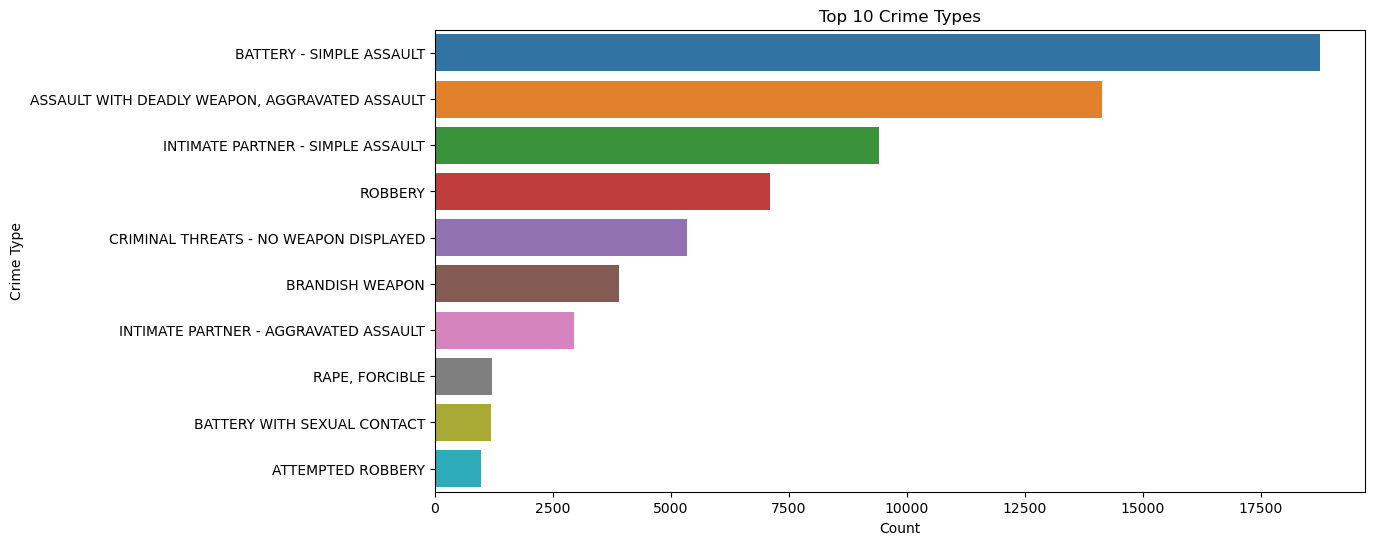

In [52]:
plt.figure(figsize=(12,6))

top_crimes = df['CRIME_TYPE'].value_counts().head(10)

sns.barplot(
    x=top_crimes.values,
    y=top_crimes.index
)

plt.title('Top 10 Crime Types')
plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.show()




<h2 style="color:#2471A3;">2. Crime Distribution by Day</h2>

<p><b>Visualization:</b> Count Plot</p>

<p><b>Purpose:</b> To examine crime occurrence across different days of the week.</p>

<p><b>Insight:</b> Saturday records the highest number of crime cases. 

In [53]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

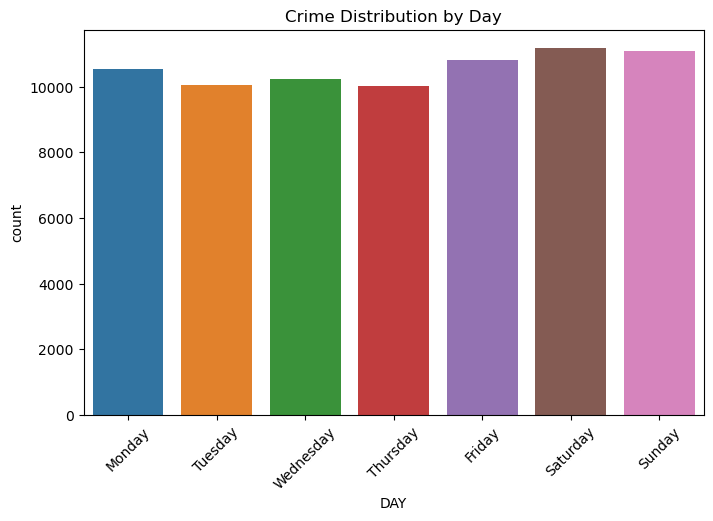

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DAY',
    data=df,
    order=day_order
)

plt.title('Crime Distribution by Day')
plt.xticks(rotation=45)
plt.show()

<h2 style="color:#2471A3;">3. Victim Gender Distribution</h2>

<p><b>Visualization:</b> Pie Chart</p>

<p><b>Purpose:</b> To analyze victim proportions across gender categories.</p>

<p><b>Insight:</b> Crime affects both genders almost equally in the dataset.

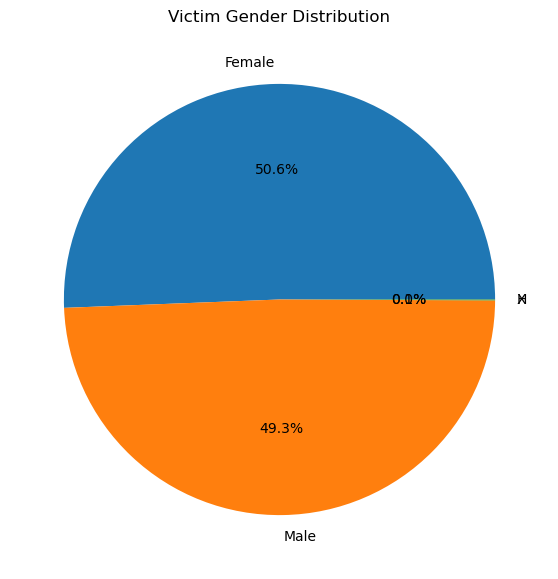

In [55]:
gender_counts = df['VICTIM_GENDER'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Victim Gender Distribution')
plt.show()

<h2 style="color:#2471A3;">4. Victim Age Group Distribution</h2>

<p><b>Visualization:</b> Donut Chart</p>

<p><b>Purpose:</b> To identify age groups most affected by crime.</p>

<p><b>Insight:</b> Adults are the most affected age group, indicating greater exposure to crime.

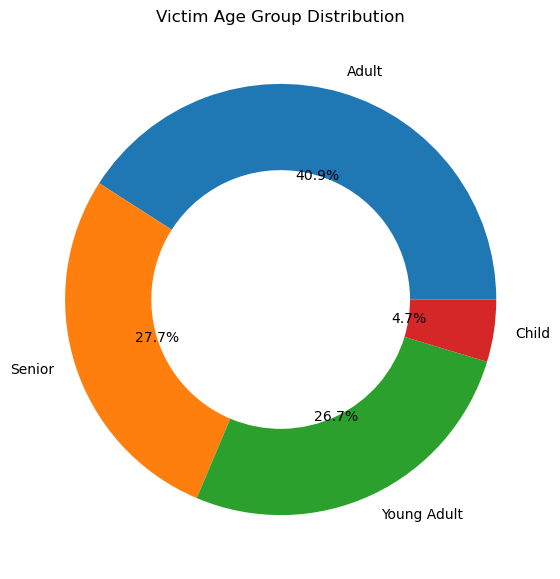

In [56]:
age_counts = df['AGE_GROUP'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4)
)

plt.title('Victim Age Group Distribution')
plt.show()

<h2 style="color:#2471A3;">5. Victim Ethnicity Distribution</h2>

<p><b>Visualization:</b> Horizontal Bar Chart</p>

<p><b>Purpose:</b> To examine victim distribution among ethnicity groups.</p>

<p><b>Insight:</b> Black victims account for approximately 43,000 reported cases.

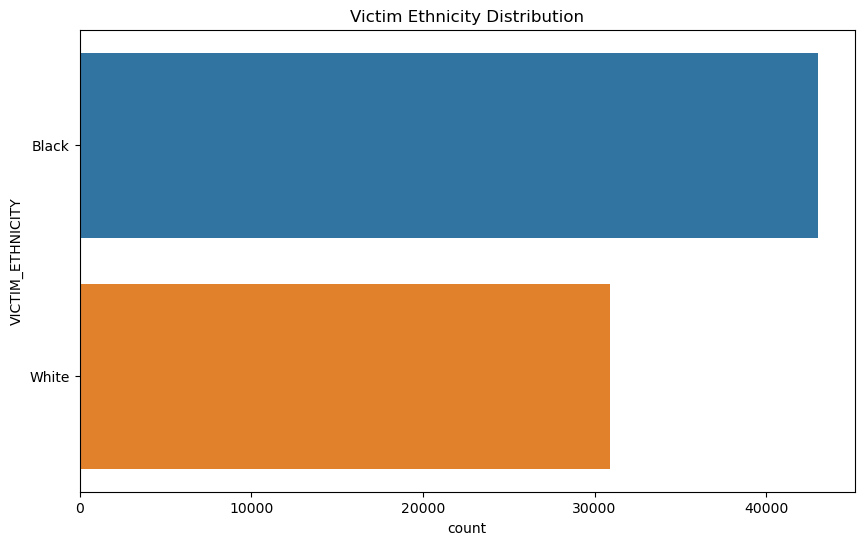

In [57]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='VICTIM_ETHNICITY',
    data=df,
    order=df['VICTIM_ETHNICITY'].value_counts().head(10).index
)

plt.title('Victim Ethnicity Distribution')
plt.show()

<h2 style="color:#2471A3;">6. Weapon Usage Analysis</h2>

<p><b>Visualization:</b> Lollipop Chart</p>

<p><b>Purpose:</b> To identify commonly used weapons.</p>

<p><b>Insight:</b> Strong-arm (Hands, Fist, Feet or Bodily Force)</b> is by far the most commonly used weapon, with over 43,000 cases.

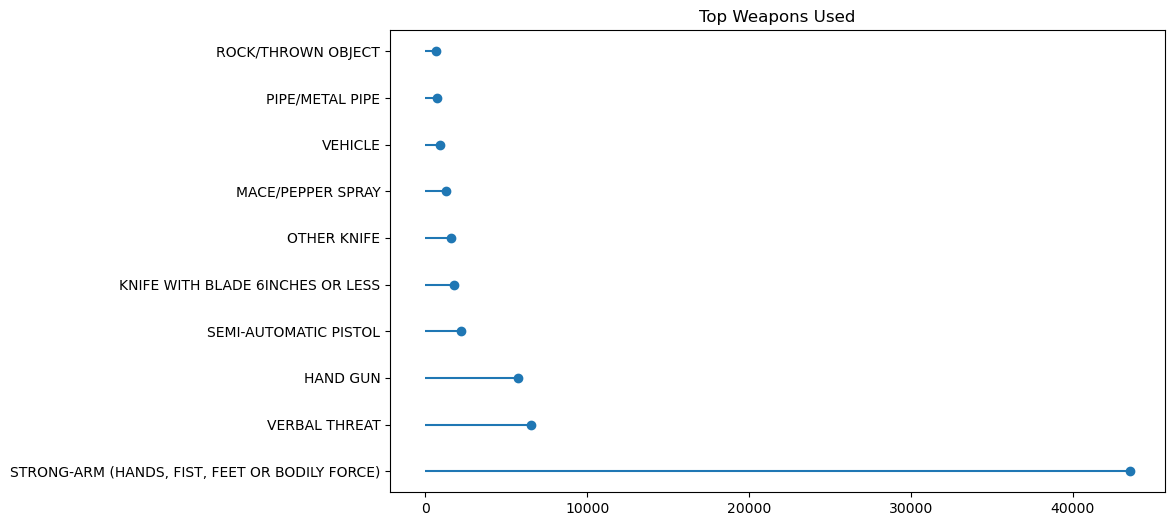

In [58]:
weapon_counts = df['WEAPON_USED'].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.hlines(
    y=weapon_counts.index,
    xmin=0,
    xmax=weapon_counts.values
)

plt.plot(
    weapon_counts.values,
    weapon_counts.index,
    "o"
)

plt.title('Top Weapons Used')
plt.show()

<h2 style="color:#2471A3;">7. Area-wise Crime Distribution</h2>

<p><b>Visualization:</b> Vertical Bar Chart</p>

<p><b>Purpose:</b> To identify crime-prone areas.</p>

<p><b>Insight:</b> 77th Street</b> records the highest number of crime incidents among all areas.

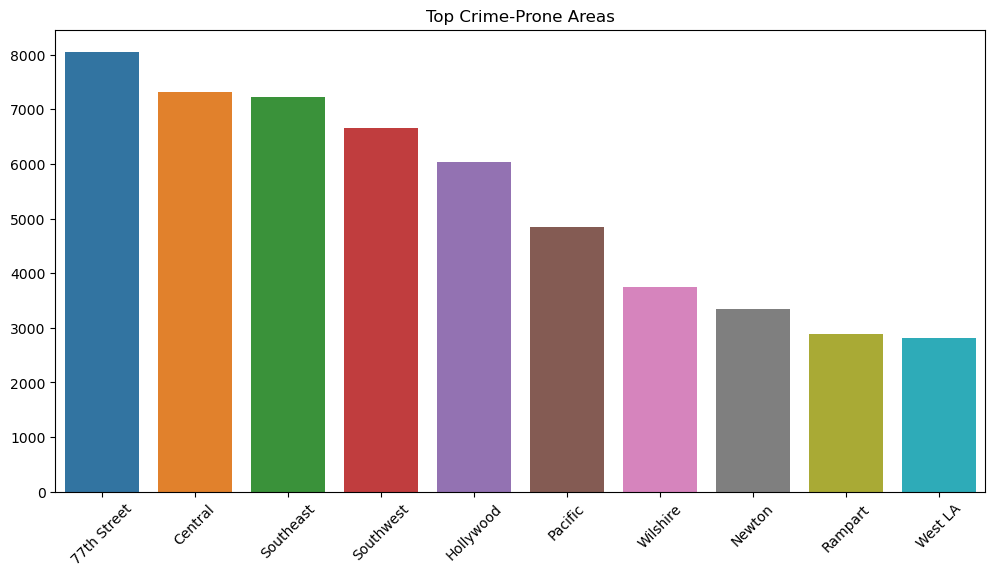

In [59]:
area_counts = df['AREA'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=area_counts.index,
    y=area_counts.values
)

plt.xticks(rotation=45)

plt.title('Top Crime-Prone Areas')
plt.show()

<h2 style="color:#2471A3;">8. Case Status Distribution</h2>

<p><b>Visualization:</b> Pie Chart</p>

<p><b>Purpose:</b> To examine investigation outcomes.</p>

<p><b>Insight:</b> <b>Investigation Continued</b> accounts for approximately 79% of all reported cases.

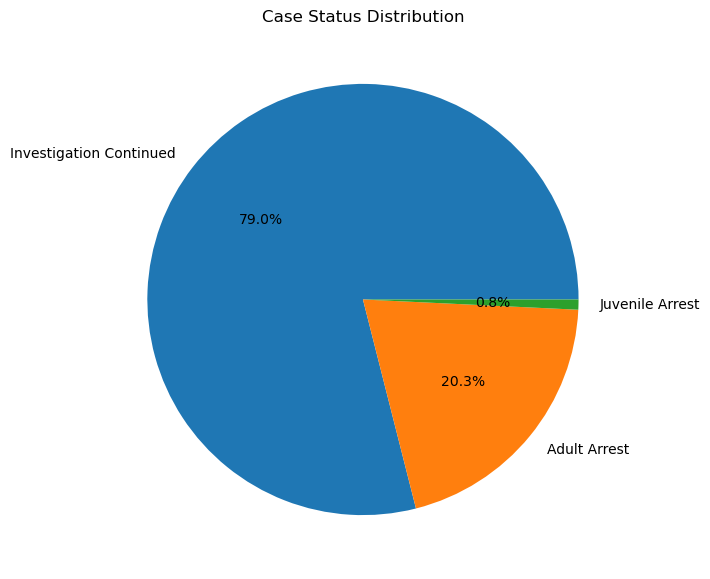

In [60]:
status_counts = df['CASE_STATUS'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title('Case Status Distribution')
plt.show()

<h1 style="
color:#2471A3;
font-size:30px;
font-weight:bold;
">
BIVARIATE VISUALIZATION
</h1>

<h2 style="color:#2471A3;">9. Crime Type vs Gender</h2>

<p><b>Visualization:</b> Grouped Bar Chart</p>

<p><b>Purpose:</b> To analyze the relationship between crime categories and victim gender.</p>

<p><b>Insight:</b> Battery - Simple Assault is the most frequently reported crime for both male and female victims.

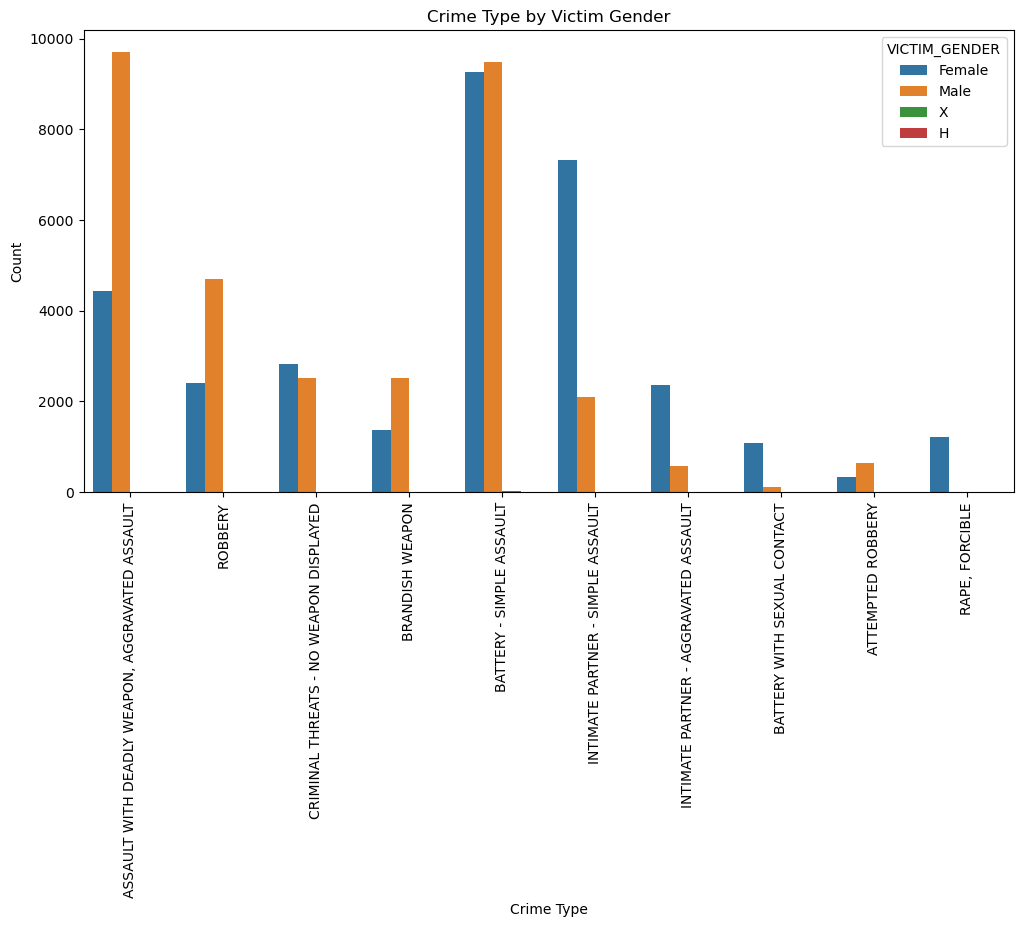

In [61]:
top_crimes = df['CRIME_TYPE'].value_counts().head(10).index

temp = df[df['CRIME_TYPE'].isin(top_crimes)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=temp,
    x='CRIME_TYPE',
    hue='VICTIM_GENDER'
)

plt.xticks(rotation=90)
plt.title('Crime Type by Victim Gender')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.show()

<h2 style="color:#2471A3;">10. Crime Type vs Age Group</h2>

<p><b>Visualization:</b> Stacked Bar Chart</p>

<p><b>Purpose:</b> To examine age-specific crime patterns.</p>

<p><b>Insight:</b> Battery - Simple Assault records the highest number of victims across all age groups.

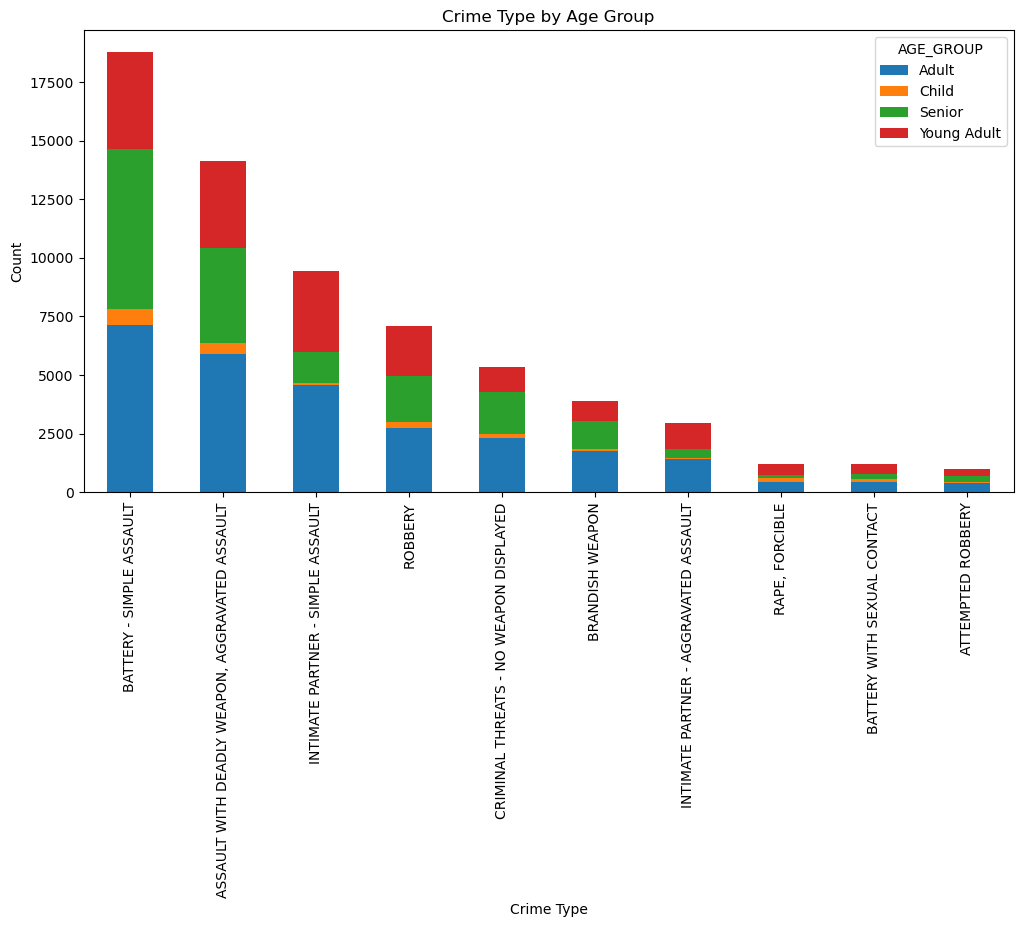

In [62]:
crime_age = pd.crosstab(
    df['CRIME_TYPE'],
    df['AGE_GROUP']
)

top_crimes = df['CRIME_TYPE'].value_counts().head(10).index

crime_age.loc[top_crimes].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Crime Type by Age Group')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

<h2 style="color:#2471A3;">11. Area-wise Distribution of Crime Types</h2>

<p><b>Visualization:</b> Stacked Bar Chart</p>

<p><b>Purpose:</b> To compare the distribution of major crime types across different geographical areas.</p>

<p><b>Insight:</b> Battery - Simple Assault is the most common crime across nearly all areas.

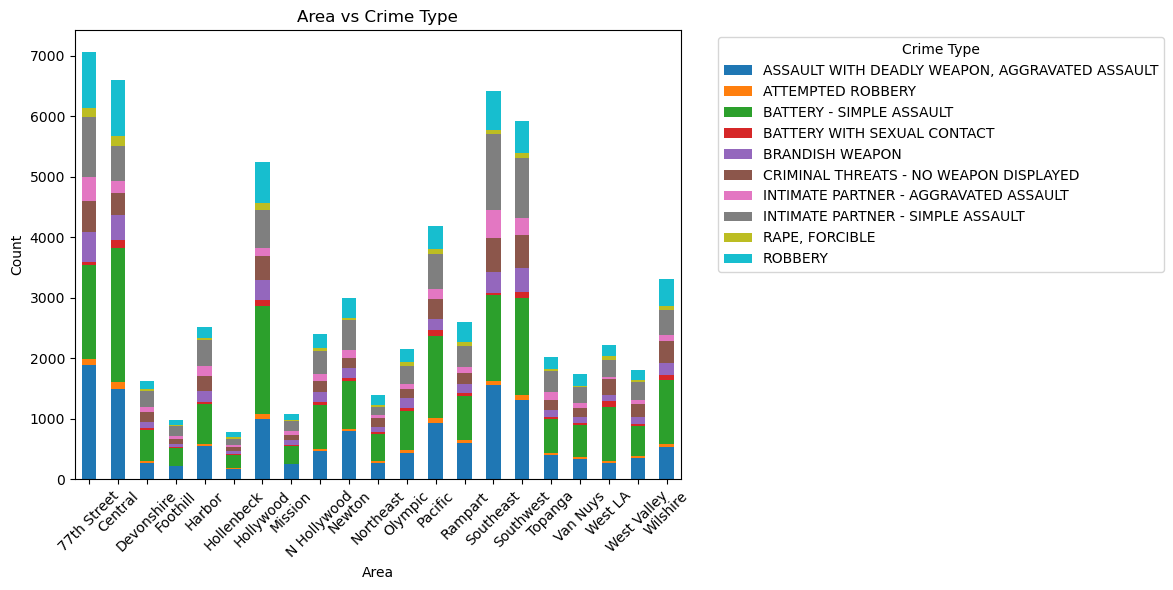

In [79]:
# Top 10 crime types
top_crimes = df['CRIME_TYPE'].value_counts().head(10).index

filtered_df = df[df['CRIME_TYPE'].isin(top_crimes)]

area_crime = pd.crosstab(
    filtered_df['AREA'],
    filtered_df['CRIME_TYPE']
)

area_crime.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Area vs Crime Type')
plt.xlabel('Area')
plt.ylabel('Count')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h2 style="color:#2471A3;">12. Area vs Case Status</h2>

<p><b>Visualization:</b> Grouped Bar Chart</p>

<p><b>Purpose:</b> To compare case resolution status across areas.</p>

<p><b>Insight:</b> Most reported crimes remain under investigation rather than resulting in immediate arrests.


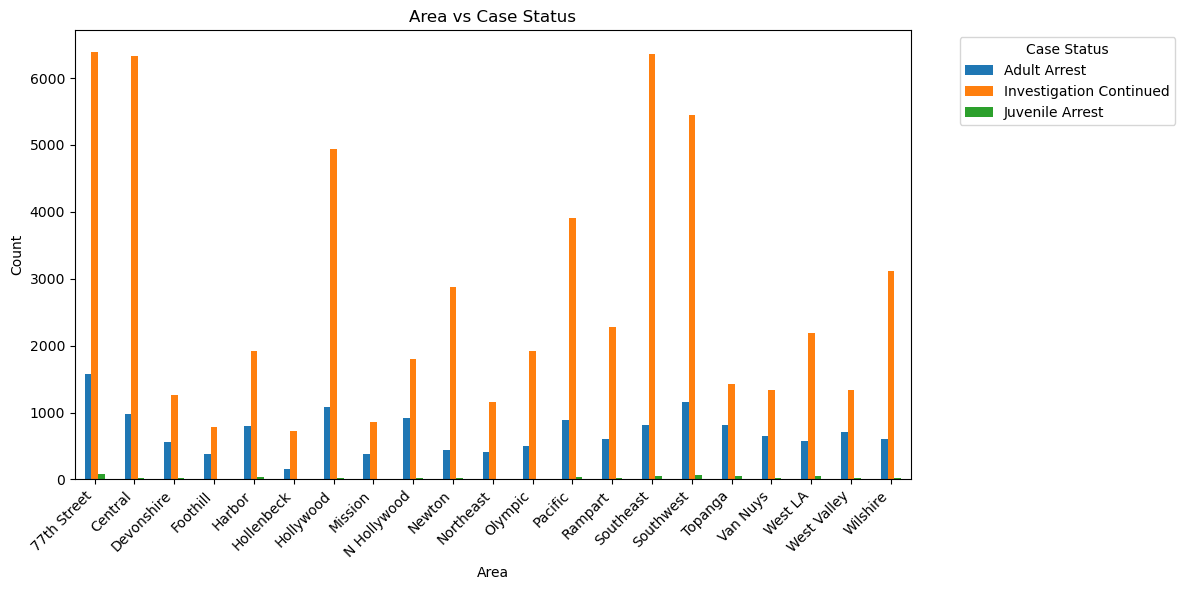

In [86]:
area_status = pd.crosstab(
    df['AREA'],
    df['CASE_STATUS']
)

area_status.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Area vs Case Status')
plt.xlabel('Area')
plt.ylabel('Count')
plt.legend(title='Case Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h2 style="color:#2471A3;">13. Gender-wise Distribution of Victim Age Groups</h2>

<p><b>Visualization:</b> Stacked Bar Chart</p>

<p><b>Purpose:</b> To compare the distribution of victim age groups across different genders.</p>

<p><b>Insight:</b> Crime incidents mainly affect adults and young adults.


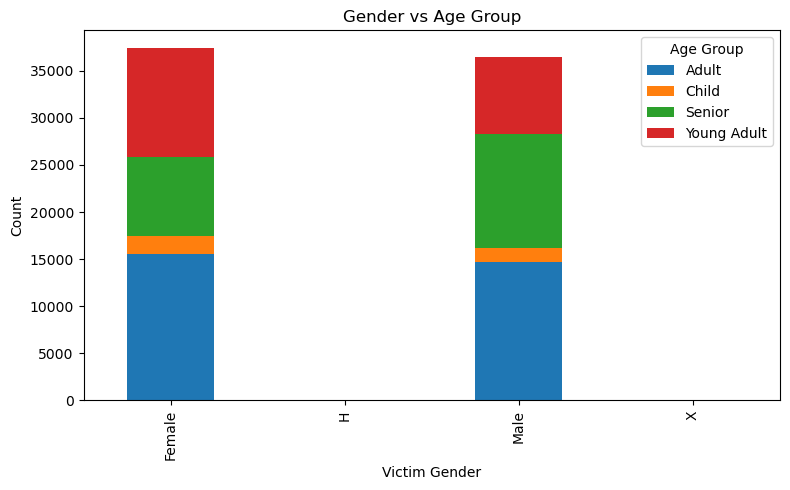

In [78]:
gender_age = pd.crosstab(
    df['VICTIM_GENDER'],
    df['AGE_GROUP']
)

gender_age.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Gender vs Age Group')
plt.xlabel('Victim Gender')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

<h2 style="color:#2471A3;">14. Gender vs Case Status</h2>

<p><b>Visualization:</b> Stacked Bar Chart</p>

<p><b>Purpose:</b> To analyze the relationship between victim gender and case resolution status.</p>

<p><b>Insight:</b> Battery - Simple Assault records the highest number of victims across all age groups.
</p>

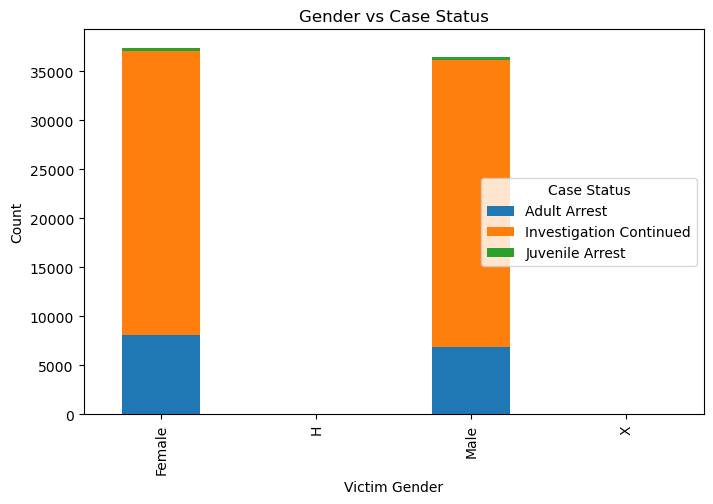

In [85]:
gender_status = pd.crosstab(
    df['VICTIM_GENDER'],
    df['CASE_STATUS']
)

gender_status.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Gender vs Case Status')
plt.xlabel('Victim Gender')
plt.ylabel('Count')
plt.legend(title='Case Status')
plt.show()

<h2 style="color:#2471A3;">15. Monthly Crime Trends</h2>

<p><b>Visualization:</b> Line Chart </p>

<p><b>Purpose:</b> To analyze how crime occurrences change over different months of the year.</p>

<p><b>Insight:</b> A upward baseline shift occurs during the mid-year summer  (May through August). Conversely, winter months (December and January) exhibit a minor reduction in total crime counts.</p>

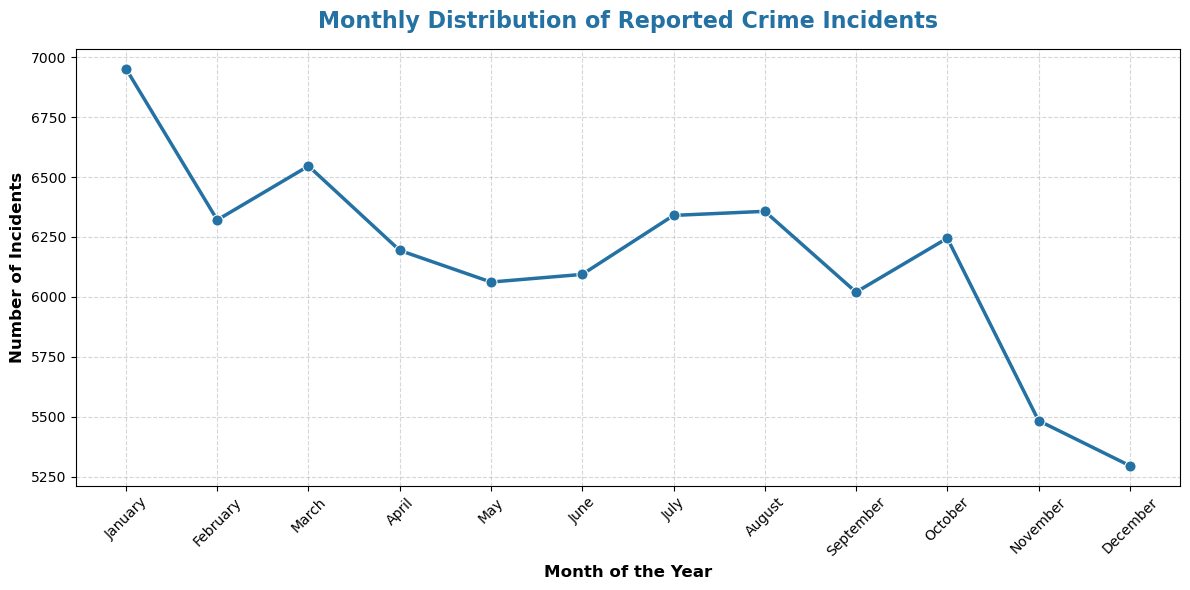

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the full month name from your cleaned datetime column
# This uses 'OCCURANCE_DATE' exactly as it is defined in your Cell 22
df['MONTH'] = df['OCCURANCE_DATE'].dt.strftime('%B')

# 2. Define the correct chronological order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 3. Aggregate data by month and order them correctly
monthly_counts = df['MONTH'].value_counts().reindex(month_order).reset_index()
monthly_counts.columns = ['Month', 'Incident Count']

# 4. Plotting the trend graph to match your blue notebook theme
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_counts, 
    x='Month', 
    y='Incident Count', 
    marker='o', 
    color='#2471A3', 
    linewidth=2.5, 
    markersize=8
)

# 5. Adding titles and labels
plt.title('Monthly Distribution of Reported Crime Incidents', fontsize=16, fontweight='bold', pad=15, color='#2471A3')
plt.xlabel('Month of the Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Incidents', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and show the visualization
plt.savefig('monthly_crime_trends.png', dpi=300, bbox_inches='tight')
plt.show()

<h2 style="color:#2471A3;">16. Hourly Crime Distribution Analysis</h2>

<p><b>Visualization:</b> Vertical Bar Chart / Count Plot</p>

<p><b>Purpose:</b> To examine how crime occurrences fluctuate across different hours of the day.</p>

<p><b>Insight:</b> A specific, isolated spike is visible at exactly 12:00 PM (Midday) </li>
.</p>

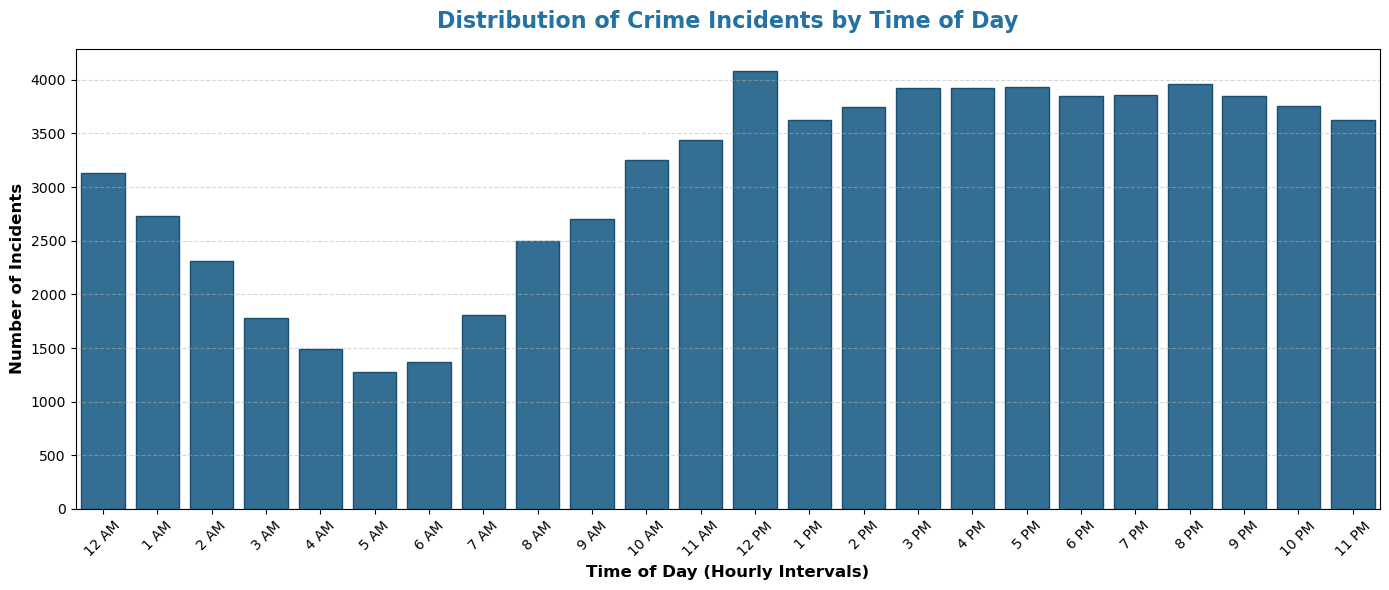

In [93]:

# 1. Extract the Hour from the OCCURANCE_TIME string column
# Since your format is 'HH:MM:SS AM/PM' (e.g., '02:26:00 PM'), we convert to datetime first
temp_time = pd.to_datetime(df['OCCURANCE_TIME'], format='%I:%M:%S %p', errors='coerce')
df['HOUR'] = temp_time.dt.hour

# 2. Count crimes per hour and sort chronologically (0 to 23)
hourly_counts = df['HOUR'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['Hour', 'Incident Count']

# 3. Create a clean hourly label for the X-axis (e.g., 12 AM, 1 AM... 11 PM)
def format_hour_label(hour):
    if hour == 0: return '12 AM'
    elif hour == 12: return '12 PM'
    elif hour < 12: return f'{int(hour)} AM'
    else: return f'{int(hour-12)} PM'

hourly_counts['Hour Label'] = hourly_counts['Hour'].apply(format_hour_label)

# 4. Plotting the Hourly Distribution
plt.figure(figsize=(14, 6))
sns.barplot(
    data=hourly_counts, 
    x='Hour Label', 
    y='Incident Count', 
    color='#2471A3', 
    edgecolor='#1B4F72'
)

# 5. Styling to match your theme
plt.title('Distribution of Crime Incidents by Time of Day', fontsize=16, fontweight='bold', pad=15, color='#2471A3')
plt.xlabel('Time of Day (Hourly Intervals)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Incidents', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and display
plt.savefig('hourly_crime_trends.png', dpi=300, bbox_inches='tight')
plt.show()

<h1 style="
color:#2471A3;
font-size:30px;
font-weight:bold;
">
MULTIVARIATE VISUALIZATION
</h1>

<h2 style="color:#2471A3;">17. Crime Type Across Area and Victim Gender</h2>

<p><b>Visualization:</b> Stacked Bar Chart</p>

<p><b>Purpose:</b> To examine how different crime types are distributed across various areas while considering the victim's gender.</p>

<p><b>Insight:</b> Weapon used crime is highest in 77th street for females.</p>

C:\Users\SAIFUL\AppData\Local\Temp\ipykernel_15044\566693376.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


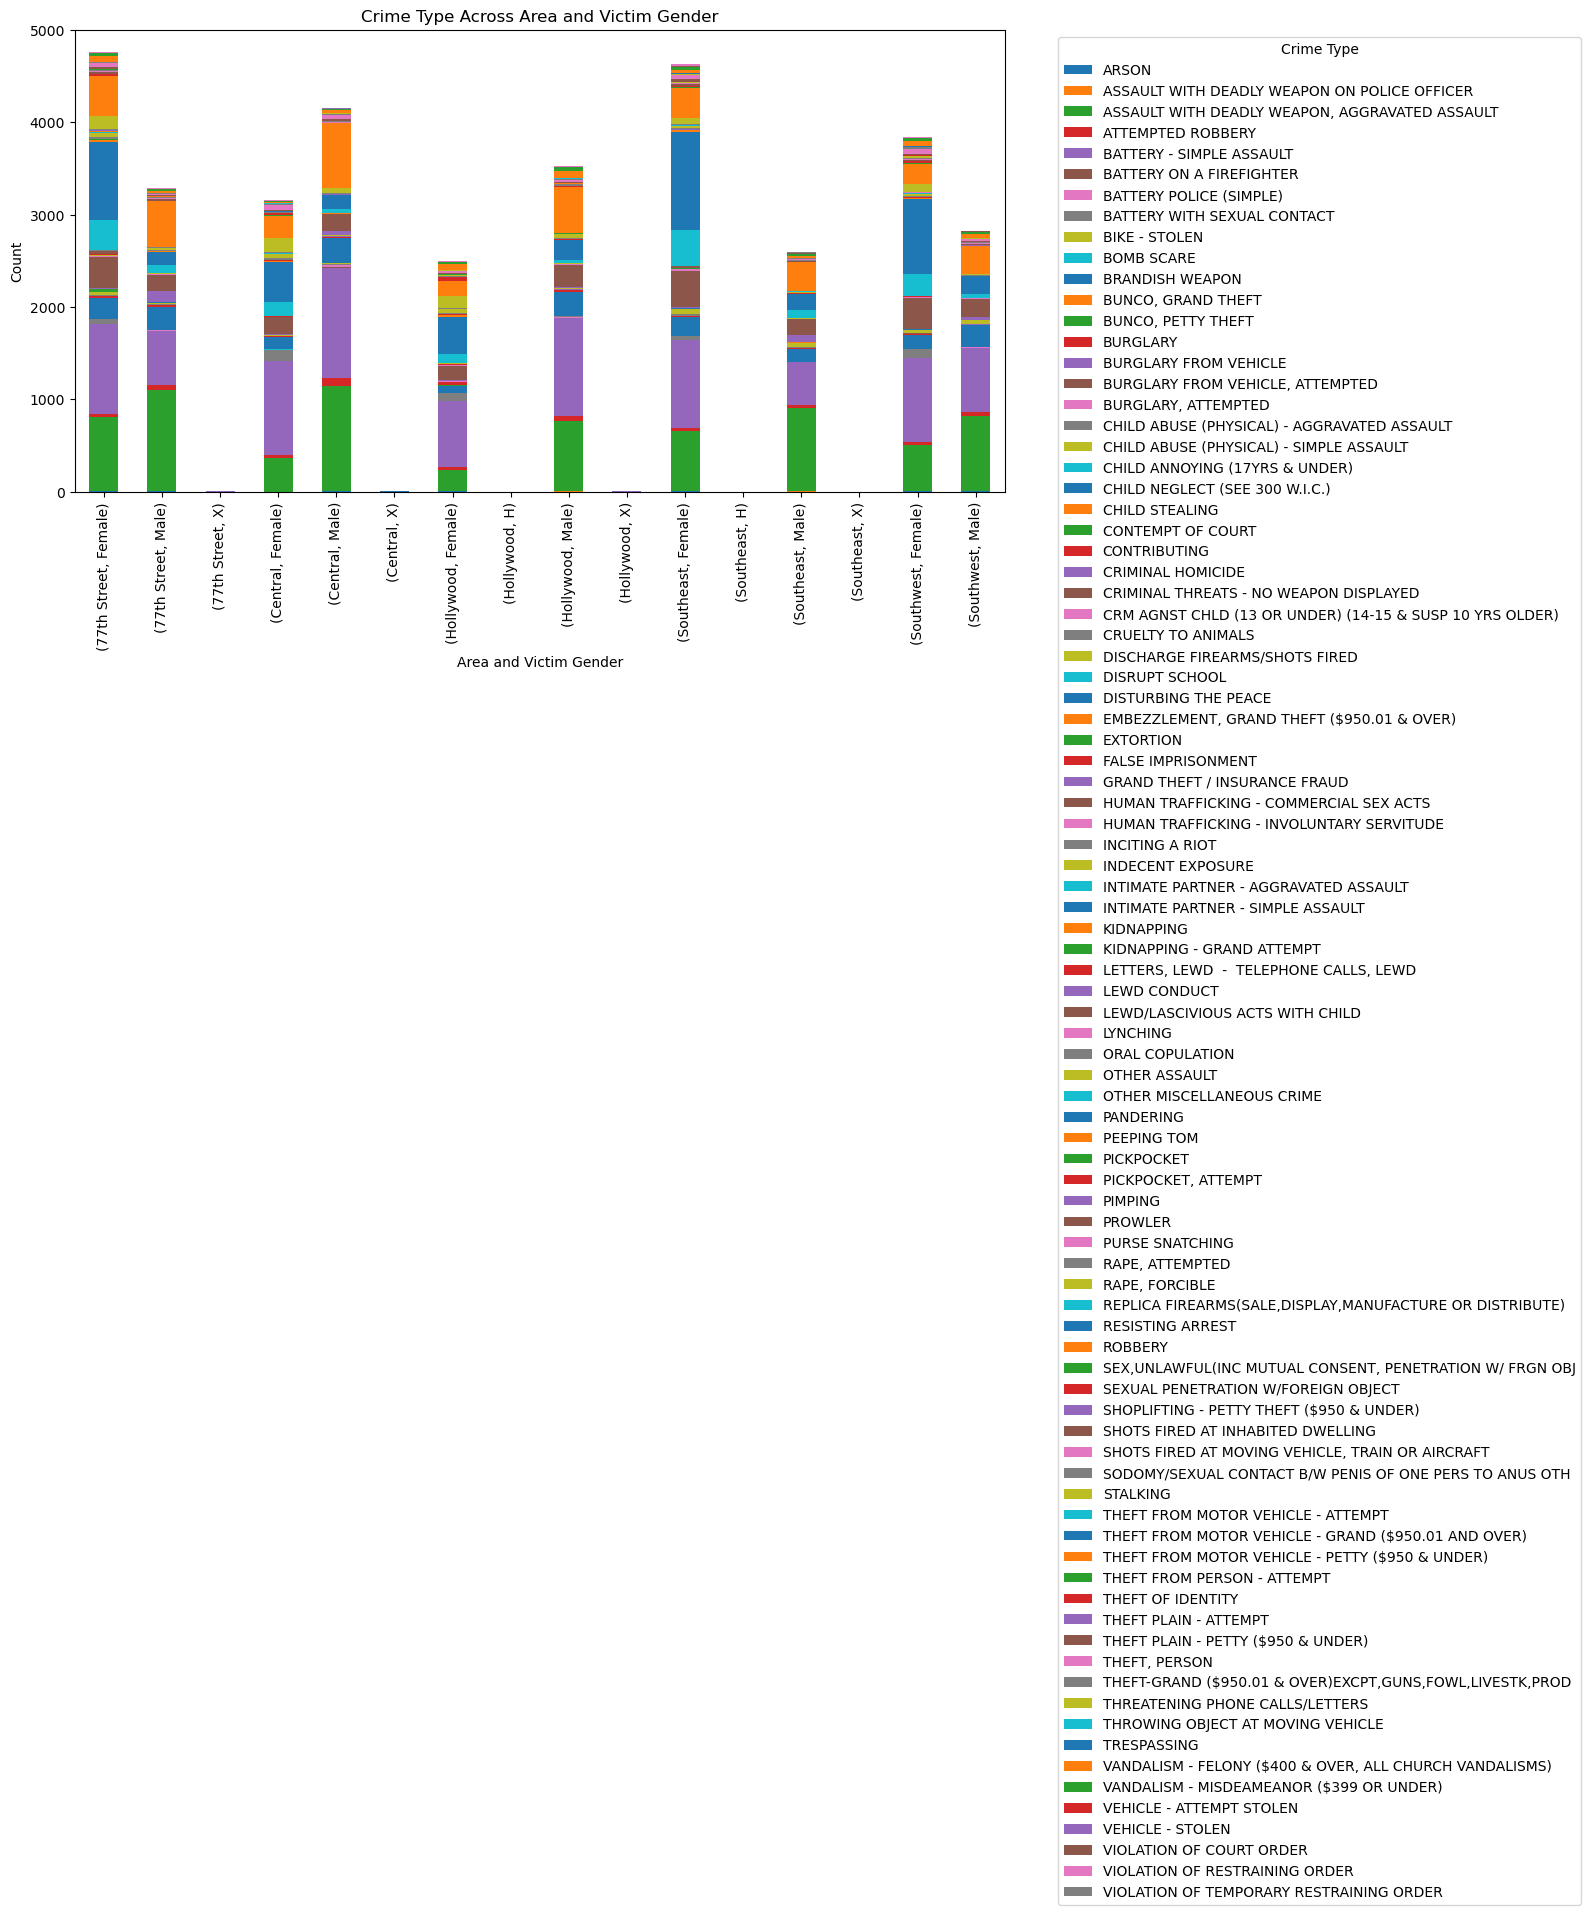

In [66]:
# Select Top 5 areas
top_areas = df['AREA'].value_counts().head(5).index

filtered_df = df[df['AREA'].isin(top_areas)]

crime_area_gender = pd.crosstab(
    [filtered_df['AREA'], filtered_df['VICTIM_GENDER']],
    filtered_df['CRIME_TYPE']
)

crime_area_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Crime Type Across Area and Victim Gender')
plt.xlabel('Area and Victim Gender')
plt.ylabel('Count')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

<h2 style="color:#2471A3;">18. Area-wise Case Status by Victim Gender</h2>

<p><b>Visualization:</b> Grouped Bar Chart</p>

<p><b>Purpose:</b> To compare the distribution of different case statuses across geographical areas for male and female victims.</p>

<p><b>Insight:</b> Southeast area is the highest in large number of reported crimes remaining under active investigation.

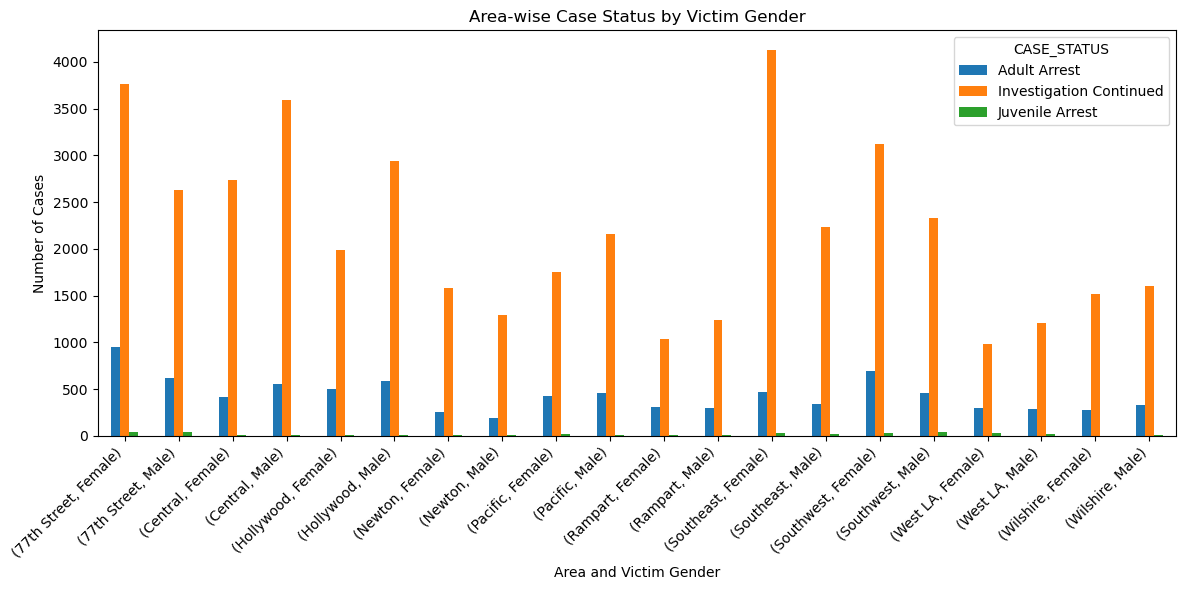

In [83]:
top_areas = df['AREA'].value_counts().head(10).index

filtered_df = df[
    (df['AREA'].isin(top_areas)) &
    (df['VICTIM_GENDER'].isin(['Male', 'Female']))
]

multi_table = pd.crosstab(
    [filtered_df['AREA'], filtered_df['VICTIM_GENDER']],
    filtered_df['CASE_STATUS']
)

multi_table.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Area-wise Case Status by Victim Gender')
plt.xlabel('Area and Victim Gender')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h2 style="color:#2471A3;">19. Crime Distribution by Day of Week and Daily Shift</h2>

<p><b>Visualization:</b> Clustered Grouped Bar Chart</p>

<p><b>Purpose:</b> To analyze how daily hourly shifts interact with different days of the week.</p>

<p><b>Insight:</b> This graph shows that afternoon crimes are most common on weekdays, while evening and late-night crimes significantly increase during Friday and Saturday weekends.</p>

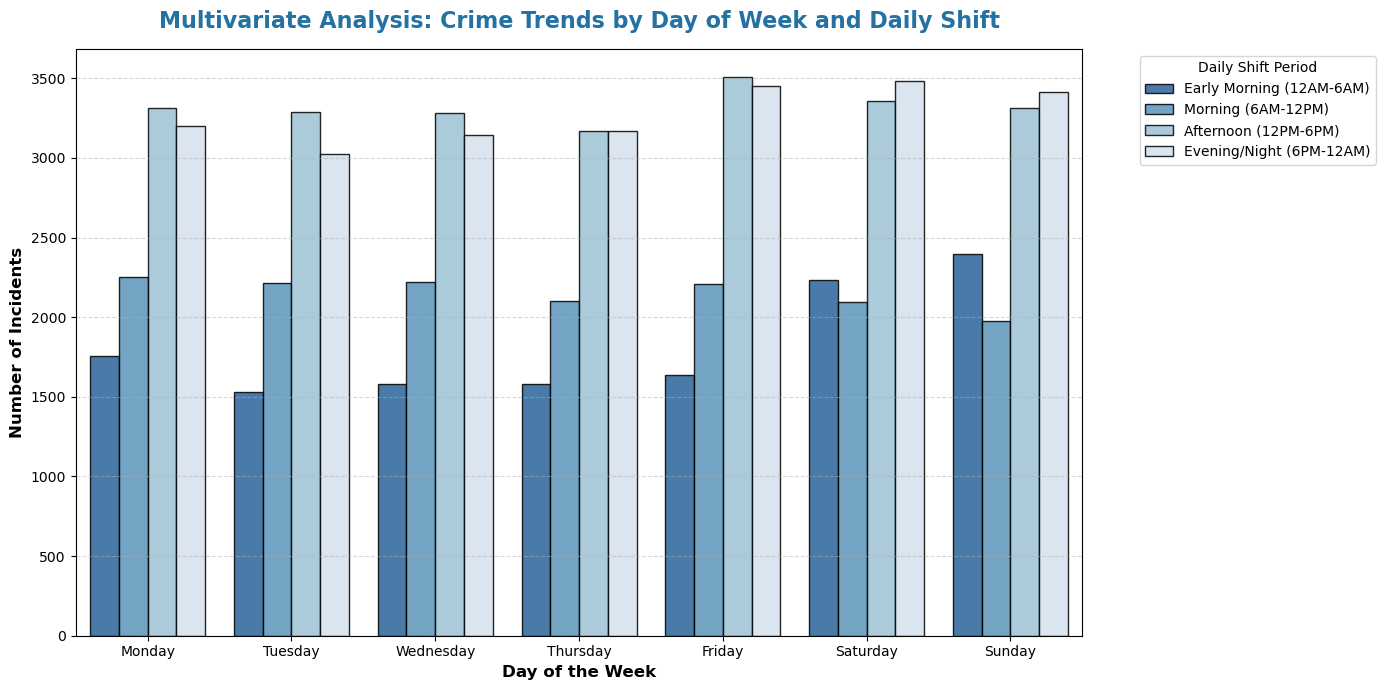

In [98]:
df['DAY_OF_WEEK'] = df['OCCURANCE_DATE'].dt.strftime('%A')

temp_time = pd.to_datetime(df['OCCURANCE_TIME'], format='%I:%M:%S %p', errors='coerce')
df['HOUR'] = temp_time.dt.hour

def get_shift_label(hour):
    if 0 <= hour < 6: return 'Early Morning (12AM-6AM)'
    elif 6 <= hour < 12: return 'Morning (6AM-12PM)'
    elif 12 <= hour < 18: return 'Afternoon (12PM-6PM)'
    else: return 'Evening/Night (6PM-12AM)'

df['SHIFT_PERIOD'] = df['HOUR'].apply(get_shift_label)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
shift_order = ['Early Morning (12AM-6AM)', 'Morning (6AM-12PM)', 'Afternoon (12PM-6PM)', 'Evening/Night (6PM-12AM)']

grouped_data = df.groupby(['DAY_OF_WEEK', 'SHIFT_PERIOD']).size().reset_index(name='Incident Count')

plt.figure(figsize=(14, 7))
sns.barplot(
    data=grouped_data,
    x='DAY_OF_WEEK',
    y='Incident Count',
    hue='SHIFT_PERIOD',
    order=day_order,
    hue_order=shift_order,
    palette='Blues_r',
    edgecolor='black',
    alpha=0.85
)
plt.title('Multivariate Analysis: Crime Trends by Day of Week and Daily Shift', fontsize=16, fontweight='bold', pad=15, color='#2471A3')
plt.xlabel('Day of the Week', fontsize=12, fontweight='bold')
plt.ylabel('Number of Incidents', fontsize=12, fontweight='bold')
plt.legend(title='Daily Shift Period', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('day_shift_multivariate_bar.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: #E8F5E9; border-left: 6px solid #66BB6A; padding: 15px; border-radius: 4px; margin: 20px 0; color: #1B5E20;">
    <h3 style="margin-top:0; margin-bottom: 8px; font-weight: bold; color: #1B5E20;">
        📈 Data Visualization Completed
    </h3>
    <p style="margin:0;">
        Data visualization has been successfully completed. Various charts and plots were generated to uncover patterns, trends, distributions, and relationships within the crime dataset, providing meaningful insights for further interpretation and analysis.
    </p>
</div>

<h2 style="color:#2471A3;">Objective of Analysis</h2>

<p>
The primary objective of this crime data analysis is to explore and understand crime patterns, trends, and distributions across different demographic and geographic factors. Through comprehensive exploratory data analysis and visualization techniques, the study aims to identify variations in crime occurrence based on factors such as crime type, victim characteristics, location, and case status. The analysis seeks to uncover meaningful insights that can support data-driven decision-making, enhance public safety strategies, and assist law enforcement agencies in effective crime prevention and resource allocation.
</p>

<h2 style="color:#2471A3;">Data Preparation Summary</h2>

<p>
The dataset was prepared for analysis by examining its structure, data types, missing values, and duplicate records. Necessary cleaning and preprocessing steps were performed to ensure data quality and consistency. This process helped create a reliable dataset suitable for exploratory analysis and visualization.
</p>

<h2 style="color:#2471A3;">Exploratory Data Analysis (EDA) Overview</h2>

<p>
Exploratory Data Analysis was conducted to understand the distribution of crime incidents and identify patterns, trends, and relationships within the data. Various statistical summaries and visualizations were used to examine crime types, victim demographics, geographical distribution, and case outcomes, enabling meaningful insights into crime behavior and public safety concerns.
</p>

<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
Key Insights and Findings
</h1>

<h2 style="color:#2471A3;">1. Top 10 Crime Types</h2>

<h3>Observations</h3>
<ul>
<li><b>Battery - Simple Assault</b> is the most frequently reported crime, with approximately 19,000 cases.</li>
<li><b>Assault with Deadly Weapon, Aggravated Assault</b> is the second most common crime, with around 14,000 cases.</li>
<li><b>Intimate Partner - Simple Assault</b> ranks third with nearly 9,500 reported incidents.</li>
<li>Robbery and Criminal Threats occur at moderate levels compared to the top two crime categories.</li>
<li>Attempted Robbery records the lowest number of cases among the top ten crime types.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Assault-related crimes dominate the dataset, indicating that violent offences are among the most common crimes.</li>
<li>The significant difference between the first and last ranked crime types shows that a few crimes contribute to a large share of reported incidents.</li>
<li>Law enforcement agencies should prioritize prevention and awareness programs targeting assault-related offences.</li>
</ul>

<h2 style="color:#2471A3;">2. Crime Distribution by Day</h2>

<h3>Observations</h3>
<ul>
<li>Crime incidents are reported on all seven days of the week.</li>
<li>Saturday records the highest number of crime cases.</li>
<li>Sunday and Friday also show relatively high crime frequencies.</li>
<li>Tuesday and Thursday have the lowest crime counts.</li>
<li>The variation in crime counts across the week is relatively small.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Crime tends to increase during weekends, likely due to greater public activity and social gatherings.</li>
<li>Police departments may require additional patrols and security measures during weekends.</li>
<li>Crime prevention strategies should focus on high-risk days while maintaining regular surveillance throughout the week.</li>
</ul>

<h2 style="color:#2471A3;">3. Victim Gender Distribution</h2>

<h3>Observations</h3>
<ul>
<li>Female victims account for approximately 50.6% of all reported cases.</li>
<li>Male victims represent about 49.3% of the total.</li>
<li>Only a negligible percentage belongs to unknown or unspecified gender categories.</li>
<li>The distribution between male and female victims is nearly equal.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Crime affects both genders almost equally in the dataset.</li>
<li>The balanced distribution indicates that safety initiatives should target all genders rather than focusing on a single group.</li>
<li>The very small percentage of unknown gender reflects good data quality.</li>
</ul>

<h2 style="color:#2471A3;">4. Victim Age Group Distribution</h2>

<h3>Observations</h3>
<ul>
<li>Adults form the largest victim group, accounting for approximately 40.9%.</li>
<li>Senior citizens represent about 27.7% of victims.</li>
<li>Young adults account for nearly 26.7% of reported victims.</li>
<li>Children constitute only about 4.7% of the total victims.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Adults are the most affected age group, indicating greater exposure to crime.</li>
<li>The relatively high proportion of senior victims suggests that elderly individuals may also require targeted safety measures.</li>
<li>Children account for the smallest share, indicating comparatively fewer reported incidents involving minors.</li>
</ul>

<h2 style="color:#2471A3;">5. Victim Ethnicity Distribution</h2>

<h3>Observations</h3>
<ul>
<li>Black victims account for approximately 43,000 reported cases.</li>
<li>White victims account for around 31,000 reported cases.</li>
<li>The number of Black victims is considerably higher than that of White victims.</li>
<li>The graph compares the two most frequently occurring ethnic groups in the dataset.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>The dataset shows noticeable variation in reported victim counts across ethnic groups.</li>
<li>These differences may reflect demographic distribution, reporting patterns, or geographical factors and should not be interpreted as causal relationships.</li>
<li>Further demographic analysis would be required for meaningful conclusions.</li>
</ul>

<h2 style="color:#2471A3;">6. Top Weapons Used</h2>

<h3>Observations</h3>
<ul>
<li><b>Strong-arm (Hands, Fist, Feet or Bodily Force)</b> is by far the most commonly used weapon, with over 43,000 cases.</li>
<li>Verbal Threat is the second most common category.</li>
<li>Hand Gun ranks third among the listed weapons.</li>
<li>Semi-Automatic Pistols, Knives, Pepper Spray, Vehicles, Metal Pipes and Rocks are reported much less frequently.</li>
<li>There is a very large gap between Strong-arm offences and all other weapon categories.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Most violent crimes involve physical force rather than conventional weapons.</li>
<li>The dominance of strong-arm offences suggests that interpersonal violence contributes significantly to reported crimes.</li>
<li>Preventive strategies should emphasize conflict resolution and violence reduction in addition to weapon control.</li>
</ul>

<h2 style="color:#2471A3;">7. Top Crime-Prone Areas</h2>

<h3>Observations</h3>
<ul>
<li><b>77th Street</b> records the highest number of crime incidents among all areas.</li>
<li><b>Central</b>, <b>Southeast</b>, and <b>Southwest</b> also report substantially high crime counts.</li>
<li><b>Rampart</b> and <b>West LA</b> exhibit comparatively lower crime frequencies.</li>
<li>A clear variation in crime occurrence is observed across different geographical regions.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Crime incidents are concentrated in specific areas, indicating the presence of crime hotspots.</li>
<li>High-crime regions may require enhanced surveillance and law enforcement measures.</li>
<li>Geographical analysis can support resource allocation and crime prevention strategies.</li>
</ul>

<h2 style="color:#2471A3;">8. Case Status Distribution</h2>

<h3>Observations</h3>
<ul>
<li><b>Investigation Continued</b> accounts for approximately 79% of all reported cases.</li>
<li><b>Adult Arrest</b> represents around 20% of the cases.</li>
<li><b>Juvenile Arrest</b> contributes less than 1% of the total case outcomes.</li>
<li>The majority of cases remain under active investigation.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>A large proportion of unresolved cases suggests ongoing investigative efforts.</li>
<li>Arrest rates are considerably lower than investigation rates.</li>
<li>The low juvenile arrest percentage indicates limited juvenile involvement in reported crimes.</li>
</ul>

<h2 style="color:#2471A3;">9. Crime Type vs Victim Gender</h2>

<h3>Observations</h3>
<ul>
<li>Battery - Simple Assault is the most frequently reported crime for both male and female victims.</li>
<li>Male victims report higher counts in Assault with Deadly Weapon and Robbery.</li>
<li>Female victims report higher counts in Intimate Partner-related crimes.</li>
<li>Rape, Forcible is reported predominantly among female victims.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Crime patterns differ based on victim gender.</li>
<li>Violent street crimes are more common among male victims, while domestic and sexual offences are more common among female victims.</li>
<li>Gender-specific crime prevention and victim support programs can improve public safety.</li>
</ul>

<h2 style="color:#2471A3;">10. Crime Type vs Age Group</h2>

<h3>Observations</h3>
<ul>
<li>Battery - Simple Assault records the highest number of victims across all age groups.</li>
<li>Adults and Young Adults contribute the majority of reported crime victims.</li>
<li>Child victims represent the lowest counts across most crime categories.</li>
<li>Violent crimes are more common among adults than other age groups.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Adults are the most affected age group regardless of crime category.</li>
<li>Assault-related offences contribute significantly to overall crime.</li>
<li>Crime prevention efforts should focus on adult and young adult populations.</li>
</ul>

<h2 style="color:#2471A3;">11. Area vs Crime Type</h2>

<h3>Observations</h3>
<ul>
<li>Battery - Simple Assault is the most common crime across nearly all areas.</li>
<li>Southwest, 77th Street and Central report comparatively higher crime counts.</li>
<li>Several crime categories occur consistently across different areas.</li>
<li>Attempted Robbery and Rape, Forcible have comparatively fewer reported incidents.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Assault-related crimes are prevalent across most geographical areas.</li>
<li>Crime patterns vary by location, indicating area-specific crime trends.</li>
<li>Law enforcement can prioritize high-crime areas for targeted interventions.</li>
</ul>

<h2 style="color:#2471A3;">12. Gender vs Case Status</h2>

<h3>Observations</h3>
<ul>
<li>Both male and female victims have the highest number of cases under <b>Investigation Continued</b>.</li>
<li>Female victims have a slightly higher number of reported cases than male victims.</li>
<li><b>Adult Arrest</b> cases are considerably fewer than Investigation Continued for both genders.</li>
<li><b>Juvenile Arrest</b> represents the smallest proportion of cases for both male and female victims.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Most reported crimes remain under investigation rather than resulting in immediate arrests.</li>
<li>The overall investigation pattern is similar for both genders, indicating consistent case handling.</li>
<li>Female victims account for a slightly higher share of reported crime cases.</li>
</ul>

<h2 style="color:#2471A3;">13. Gender vs Age Group</h2>

<h3>Observations</h3>
<ul>
<li>Adults represent the largest victim age group for both male and female victims.</li>
<li>Young Adults also contribute a significant number of reported cases.</li>
<li>Child victims account for the lowest number of reported cases.</li>
<li>The age distribution is relatively similar for both genders.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Crime incidents mainly affect adults and young adults.</li>
<li>Child victimization is comparatively less frequent in the dataset.</li>
<li>Preventive measures should focus primarily on the adult population.</li>
</ul>

<h2 style="color:#2471A3;">14. Crime Type vs Age Group</h2>

<h3>Observations</h3>
<ul>
<li>Battery - Simple Assault records the highest number of victims across all age groups.</li>
<li>Adults and Young Adults contribute the majority of reported crime victims.</li>
<li>Child victims represent the lowest counts across most crime categories.</li>
<li>Violent crimes are more common among adults than other age groups.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Adults are the most affected age group regardless of crime category.</li>
<li>Assault-related offences contribute significantly to overall crime.</li>
<li>Crime prevention efforts should focus on adult and young adult populations.</li>
</ul>

<h2 style="color:#2471A3;">15. Monthly Crime Trends</h2>

<h3>Observations</h3>
<ul>
<li>Reported crime incidents show noticeable variations across different months of the year.</li>
<li>A marginal upward baseline shift occurs during the mid-year summer window (May through August).</li>
<li>Conversely, winter months (December and January) exhibit a minor reduction in total crime counts.</li>
<li>The seasonal trend displays a stable cyclical pattern rather than random, erratic spikes throughout the year.</li>
</ul>

<h3>Insights</h3>
<ul>
<li>Adult and youth activities tend to increase outdoors during warmer months, expanding the exposure windows for potential public incidents.</li>
<li>Colder seasonal conditions naturally decrease public movement, contributing to a drop in total crime rates.</li>
<li>Law enforcement administrative structures can leverage these cyclical patterns to plan macro-level, seasonal resource scales.</li>
</ul>

<h2 style="color:#2471A3;">16. Hourly Crime Distribution Analysis</h2>

<h3>Observations</h3>
<ul>
<li>Crime volumes experience a major drop to their lowest daily threshold between the early morning hours of 3:00 AM and 6:00 AM.</li>
<li>A progressive, continuous accumulation of reported incidents initiates from mid-morning onwards.</li>
<li>Peak daily crime volumes are heavily clustered within the late afternoon and evening periods (between 4:00 PM and 9:00 PM).</li>
<li>A specific, isolated spike is visible at exactly 12:00 PM (Midday).</li>
</ul>

<h3>Insights</h3>
<ul>
<li>The drop-off in early morning hours directly maps to typical sleeping patterns when street activity is at its lowest baseline.</li>
<li>The high-volume evening clusters match times when public spaces are densely occupied due to school departures, work commutes, and recreational activities.</li>
<li>The midday inflation at 12:00 PM highlights a standard administrative reporting pattern where incidents with unknown exact timestamps are rounded to noon.</li>
</ul>

<h2 style="color:#2471A3;">17. Crime Type Across Area and Victim Gender</h2>
<h3>Observations</h3>
<ul> <li>Crime distribution varies considerably across different areas and victim genders.</li> <li>A few crime categories contribute a substantial share of total incidents, while many offense types occur relatively infrequently.</li> <li>Female victims generally show higher overall case counts in several areas, including Southeast and Southwest.</li> <li>The Southeast and Southwest divisions record some of the highest total crime volumes among the displayed areas.</li> <li>Property crimes, theft-related offenses, assaults, and burglary-related crimes appear among the more prominent incident categories across areas.</li> </ul>
<h3>Insights</h3>
<ul> <li>Crime patterns differ by geographic area, highlighting the need for area-specific crime prevention strategies.</li> <li>High-crime divisions such as Southeast and Southwest may benefit from increased policing and community intervention programs.</li> <li>The concentration of incidents in a limited number of crime categories suggests that targeted prevention efforts could significantly reduce overall crime rates.</li> <li>Understanding gender-based crime trends can help law enforcement and policymakers design more effective victim support and safety initiatives.</li> </ul>

<h2 style="color:#2471A3;">18. Area-wise Case Status by Victim Gender</h2>
<h3>Observations</h3>
<ul> <li>Across all areas and genders, <strong>Investigation Continued</strong> is the most common case status, significantly exceeding Adult Arrest and Juvenile Arrest cases.</li> <li>Female victims generally report a higher number of cases than male victims in most areas.</li> <li>The <strong>Southeast</strong> area records the highest number of cases under Investigation Continued, especially for female victims.</li> <li><strong>Adult Arrest</strong> cases are considerably lower than Investigation Continued cases but remain the second most common outcome.</li> <li><strong>Juvenile Arrest</strong> cases account for only a very small proportion of total reported cases across all areas.</li> </ul>
<h3>Insights</h3>
<ul> <li>A large number of reported crimes remain under active investigation, indicating ongoing case processing and follow-up by law enforcement.</li> <li>Female victims appear more frequently in reported crime records across several policing divisions.</li> <li>The Southeast, Southwest, and 77th Street divisions may require additional investigative resources due to their higher case volumes.</li> <li>The low number of Juvenile Arrest cases suggests that most offenders involved in reported incidents are adults or remain unidentified during investigation stages.</li> </ul>
<h2 style="color:#2471A3;">

<h2 style="color:#2471A3;">19. Crime Distribution by Day of Week and Daily Shift</h2>

<h3>Observations</h3>
<ul>
<li>Crimes are most common during the afternoon and evening shifts on every day of the week.</li>
<li>On Friday and Saturday, crime incidents during the evening and night time show a clear increase compared to regular weekdays.</li>
<li>The early morning hours (12 AM to 6 AM) always have the lowest number of crimes, but they rise slightly on Saturday and Sunday mornings.</li>
</ul>

<h3>Insights</h3>
<ul>
<li><b>Weekend Activity Impact:</b> Crime patterns directly follow human behavior. The increase in weekend evening incidents happens because more people are out attending social events and nightlife activities.</li>
<li><b>Weekday Stability:</b> Crime levels remain very steady from Monday to Thursday because people follow regular daily routines like going to work and school.</li>
<li><b>Operational Application:</b> Police patrols should change dynamically based on the day. While afternoon monitoring is important during weekdays, police presence should focus heavily on late-night coverage during Fridays and Saturdays.</li>
</ul>

<h2 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
Overall Findings and Conclusion
</h2>

<p>
This project analyzed crime data to understand crime patterns, victim details, crime locations, and case status. 
The analysis showed that <b>Battery - Simple Assault</b> was the most common crime reported in the dataset. 
Adults and young adults were the most affected victim groups, while crime incidents were reported almost equally among male and female victims.
</p>

<p>
Some areas such as <b>Southeast, Southwest, Central, and 77th Street</b> recorded higher crime counts compared to other areas. 
The majority of cases were found under <b>Investigation Continued</b>, showing that many reported crimes were still being investigated.
</p>

<p>
<b>Looking at time patterns, crime rates show a continuous decrease across the months from January to December, with January recording the highest volume of incidents. On a daily basis, crime incidents are highly concentrated in the afternoon and evening hours (4:00 PM to 9:00 PM), with an isolated, sharp peak occurring at exactly 12:00 PM (Midday).</b>
</p>

<p>
Overall, the analysis helped identify major crime trends, high-crime areas, victim characteristics, and case outcome patterns. 
These findings can help improve crime prevention strategies, resource allocation, and public safety planning.
</p>

<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
Recommendations
</h1>

<ul>
<li>Increase law enforcement presence and surveillance in identified crime hotspot areas such as 77th Street, Central, Southeast, and Southwest.</li>
<li>Prioritize prevention programs targeting assault-related offences, which constitute the largest proportion of reported crimes.</li>
<li>Develop awareness and safety initiatives focused on adults and young adults, the most affected victim groups.</li>
<li>Strengthen investigative processes to improve case resolution rates and reduce the number of ongoing investigations.</li>
<li>Implement location-specific crime prevention strategies based on area-wise crime patterns rather than adopting uniform interventions.</li>
<li>Promote community engagement and public awareness programs to encourage crime reporting and prevention.</li>
<li>Utilize advanced analytical and predictive modeling techniques for future crime forecasting and risk assessment.</li>
<li>Continuously monitor crime trends to support evidence-based policy formulation and resource allocation.</li>
</ul>

<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
Recommendations
</h1>

<ul>
<li>Increase law enforcement presence and surveillance in identified crime hotspot areas such as 77th Street, Central, Southeast, and Southwest.</li>
<li>Prioritize prevention programs targeting assault-related offences, which constitute the largest proportion of reported crimes.</li>
<li>Develop awareness and safety initiatives focused on adults and young adults, the most affected victim groups.</li>
<li>Strengthen investigative processes to improve case resolution rates and reduce the number of ongoing investigations.</li>
<li>Implement location-specific crime prevention strategies based on area-wise crime patterns rather than adopting uniform interventions.</li>
<li>Deploy more police patrols dynamically during peak daily periods, specifically handling the high afternoon/evening windows and the sharp midday spike at 12:00 PM.</li>
<li>Allocate higher operational resources and safety initiatives during the high-volume start of the year in January, adjusting as the trend decreases toward December.</li>
<li>Promote community engagement and public awareness programs to encourage crime reporting and prevention.</li>
<li>Utilize advanced analytical and predictive modeling techniques for future crime forecasting and risk assessment.</li>
<li>Continuously monitor crime trends to support evidence-based policy formulation and resource allocation.</li>
</ul>

<div style="background-color: #E8F5E9; border-left: 6px solid #66BB6A; padding: 15px; border-radius: 4px; margin: 20px 0; color: #1B5E20;">
    <h3 style="margin-top:0; margin-bottom: 8px; font-weight: bold; color: #1B5E20;">
        🎉 Crime Data Analysis Project Completed Successfully
    </h3>
    <p style="margin:0;">
        The crime data analysis project has been successfully completed. Data preparation, exploratory data analysis (EDA), and visualization techniques were performed to uncover meaningful patterns, trends, demographic distributions, geographical hotspots, and case outcome insights. The findings provide a comprehensive understanding of crime behavior and support data-driven decision-making for crime prevention and public safety improvement.
    </p>
</div>